In [ ]:
# full_pipeline_no_leakage.py
# Run: python full_pipeline_no_leakage.py  (or paste into a notebook cell)

import traceback
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


def main(path_df1="/content/diabetes.csv", path_df2="/content/Balanced_HRP_DataSet.csv"):
    try:
        # -------------------------
        # 1. LOAD DATA
        # -------------------------
        print("Loading data...")
        df1 = pd.read_csv(path_df1)
        df2 = pd.read_csv(path_df2)

        print("df1 columns:", df1.columns.tolist())
        print("df2 columns:", df2.columns.tolist())

        # -------------------------
        # 2. OPTIONAL RENAMING
        # -------------------------
        # adjust these only if the names exist in df1 or df2
        if "Glucose" in df1.columns:
            df1 = df1.rename(columns={"Glucose": "Blood Sugar"})
        if "BloodPressure" in df1.columns:
            df1 = df1.rename(columns={"BloodPressure": "DiastolicBP"})

        # If df2 uses different names, rename accordingly here (example):
        # df2 = df2.rename(columns={"GlucoseVal": "Blood Sugar", "BP": "DiastolicBP"})

        # -------------------------
        # 3. MERGE (INNER JOIN)
        # -------------------------
        merge_cols = ["Blood Sugar", "DiastolicBP"]
        for c in merge_cols:
            if c not in df1.columns or c not in df2.columns:
                raise ValueError(f"Merge column '{c}' missing in one of the dataframes. Check column names.")

        merged_df = pd.merge(df1, df2, on=merge_cols, how="inner", suffixes=("_d1", "_d2"))
        print("Merged Data Shape:", merged_df.shape)
        if merged_df.shape[0] == 0:
            raise ValueError("Merge returned 0 rows. Check merging keys and values.")

        # -------------------------
        # 4. TARGET COLUMN
        # -------------------------
        # Try common names; change this list if your label has a different name.
        target_candidates = ["Outcome", "RiskLevel", "risk", "Outcome_d1", "Outcome_d2"]
        target_col = None
        for t in target_candidates:
            if t in merged_df.columns:
                target_col = t
                break
        if target_col is None:
            raise ValueError(f"No target column found among candidates: {target_candidates}. Please set target explicitly.")
        print("Using target column:", target_col)

        # -------------------------
        # 5. SPLIT FIRST (no leakage)
        # -------------------------
        X = merged_df.drop(columns=[target_col]).copy()
        y = merged_df[target_col].copy()

        # If y is object -> convert to numeric codes
        if y.dtype == object:
            y = y.astype("category").cat.codes
            print("Converted target to numeric category codes.")

        # Use stratify when possible
        stratify_arg = y if len(np.unique(y)) > 1 else None
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=42, stratify=stratify_arg
        )
        print("Train shape:", X_train.shape, y_train.shape)
        print("Test shape:", X_test.shape, y_test.shape)

        # -------------------------
        # 6. PREPROCESSING (fit on train only)
        # -------------------------
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

        print("Numeric columns:", numeric_cols)
        print("Categorical columns:", categorical_cols)

        # numeric pipeline: median impute -> scale
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        # categorical pipeline: mode impute -> one-hot (handle_unknown safe)
        # NOTE: avoid sparse=False for maximum sklearn compatibility
        if len(categorical_cols) > 0:
            categorical_transformer = Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ])
            transformers = [
                ("num", numeric_transformer, numeric_cols),
                ("cat", categorical_transformer, categorical_cols)
            ]
        else:
            # no categorical columns present
            transformers = [
                ("num", numeric_transformer, numeric_cols)
            ]

        preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

        # Fit on train
        X_train_prep = preprocessor.fit_transform(X_train)
        X_test_prep = preprocessor.transform(X_test)

        print("After preprocessing, X_train_prep shape:", X_train_prep.shape)
        print("After preprocessing, X_test_prep shape:", X_test_prep.shape)

        # -------------------------
        # 7. PCA (fit on train only)
        # -------------------------
        # Only apply PCA if more than 1 feature present
        if X_train_prep.shape[1] < 2:
            print("Not enough features for PCA. Skipping PCA.")
            X_train_final = X_train_prep
            X_test_final = X_test_prep
        else:
            pca = PCA(n_components=0.95, svd_solver="full")
            X_train_final = pca.fit_transform(X_train_prep)
            X_test_final = pca.transform(X_test_prep)
            print("After PCA, shapes:", X_train_final.shape, X_test_final.shape)
            print("Explained variance ratio sum:", np.sum(pca.explained_variance_ratio_))

        # -------------------------
        # 8. MODELING
        # -------------------------
        # Random Forest
        rf = RandomForestClassifier(n_estimators=200, random_state=42)
        rf.fit(X_train_final, y_train)
        rf_pred = rf.predict(X_test_final)

        print("\n===== RANDOM FOREST RESULTS =====")
        print("Accuracy:", accuracy_score(y_test, rf_pred))
        print("Confusion matrix:\n", confusion_matrix(y_test, rf_pred))
        print(classification_report(y_test, rf_pred))

        # XGBoost
        # Note: older xgboost versions may not like use_label_encoder param; we include eval_metric
        xgb_params = {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 6, "eval_metric": "logloss"}
        try:
            xgb = XGBClassifier(**xgb_params, use_label_encoder=False)
        except TypeError:
            # fallback for older xgboost that doesn't support use_label_encoder
            xgb = XGBClassifier(**xgb_params)
        xgb.fit(X_train_final, y_train)
        xgb_pred = xgb.predict(X_test_final)

        print("\n===== XGBOOST RESULTS =====")
        print("Accuracy:", accuracy_score(y_test, xgb_pred))
        print("Confusion matrix:\n", confusion_matrix(y_test, xgb_pred))
        print(classification_report(y_test, xgb_pred))

        # -------------------------
        # 9. OPTIONAL: Return fitted objects if needed
        # -------------------------
        return {
            "preprocessor": preprocessor,
            "pca": locals().get("pca", None),
            "rf": rf,
            "xgb": xgb
        }

    except Exception as e:
        print("ERROR DURING PIPELINE EXECUTION:")
        traceback.print_exc()
        raise


if __name__ == "__main__":
    # Replace paths below if your files are located elsewhere
    main(path_df1="/content/diabetes.csv", path_df2="/content/Balanced_HRP_DataSet.csv")


Loading data...
df1 columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df2 columns: ['Age', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate', 'RiskLevel']
Merged Data Shape: (332, 22)
Using target column: Outcome
Train shape: (249, 21) (249,)
Test shape: (83, 21) (83,)
Numeric columns: ['Pregnancies', 'Blood Sugar', 'DiastolicBP', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age_d1', 'Age_d2', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate']
Categorical columns: ['RiskLevel']
After preprocessing, X_train_prep shape: (249, 22)
After preprocessing, X_test_prep shape: (83, 22)
After PCA, shapes: (249, 17) (

In [ ]:
# full_pipeline_with_cv_tuning_and_persistence.py
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import traceback

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

import time

def run_pipeline(path_df1="/content/diabetes.csv", path_df2="/content/Balanced_HRP_DataSet.csv",
                 random_state=42, n_iter_search=40, cv_folds=5):
    try:
        t0 = time.time()
        print("Loading data...")
        df1 = pd.read_csv(path_df1)
        df2 = pd.read_csv(path_df2)
        print("df1 columns:", df1.columns.tolist())
        print("df2 columns:", df2.columns.tolist())

        # Optional renaming (adjust if required)
        if "Glucose" in df1.columns:
            df1 = df1.rename(columns={"Glucose": "Blood Sugar"})
        if "BloodPressure" in df1.columns:
            df1 = df1.rename(columns={"BloodPressure": "DiastolicBP"})

        merge_cols = ["Blood Sugar", "DiastolicBP"]
        for c in merge_cols:
            if c not in df1.columns or c not in df2.columns:
                raise ValueError(f"Merge column '{c}' missing in one of the dataframes. Check column names.")

        merged_df = pd.merge(df1, df2, on=merge_cols, how="inner", suffixes=("_d1","_d2"))
        print("Merged Data Shape:", merged_df.shape)
        if merged_df.shape[0] == 0:
            raise ValueError("Merge returned 0 rows. Check merging keys and values.")

        # Detect target column
        target_candidates = ["Outcome", "RiskLevel", "risk", "Outcome_d1", "Outcome_d2"]
        target_col = None
        for t in target_candidates:
            if t in merged_df.columns:
                target_col = t
                break
        if target_col is None:
            raise ValueError(f"No target column found among candidates: {target_candidates}. Please set target explicitly.")
        print("Using target column:", target_col)

        X = merged_df.drop(columns=[target_col]).copy()
        y = merged_df[target_col].copy()
        if y.dtype == object:
            y = y.astype("category").cat.codes
            print("Converted target to numeric category codes.")

        # First split (no leakage)
        stratify_arg = y if len(np.unique(y)) > 1 else None
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=random_state, stratify=stratify_arg
        )
        print("Train shape:", X_train.shape, y_train.shape)
        print("Test shape:", X_test.shape, y_test.shape)

        # Identify numeric / categorical columns from training set
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
        print("Numeric columns:", numeric_cols)
        print("Categorical columns:", categorical_cols)

        # Preprocessing pipelines
        numeric_transformer = SkPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        if len(categorical_cols) > 0:
            categorical_transformer = SkPipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))  # no sparse=False for compat
            ])
            preprocessor = ColumnTransformer(transformers=[
                ("num", numeric_transformer, numeric_cols),
                ("cat", categorical_transformer, categorical_cols)
            ], remainder="drop")
        else:
            preprocessor = ColumnTransformer(transformers=[
                ("num", numeric_transformer, numeric_cols),
            ], remainder="drop")

        # ---------- Pipelines (imblearn) ----------
        # We include a named 'smote' step which we will toggle between SMOTE() and 'passthrough' in the search grid
        rf_pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=random_state)),
            ("pca", PCA(n_components=0.95, svd_solver="full")),
            ("clf", RandomForestClassifier(random_state=random_state))
        ])

        xgb_pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=random_state)),
            ("pca", PCA(n_components=0.95, svd_solver="full")),
            ("clf", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="logloss"))
        ])

        # ---------- Hyperparameter distributions (RandomizedSearch) ----------
        # RandomForest search space (use randint/uniform for RandomizedSearchCV)
        rf_param_dist = {
            # toggle SMOTE or skip
            "smote": [SMOTE(random_state=random_state), "passthrough"],
            "clf__n_estimators": randint(50, 400),
            "clf__max_depth": randint(3, 30),
            # try class_weight options (None or 'balanced')
            "clf__class_weight": [None, "balanced"],
            "clf__max_features": ["sqrt", "log2", None]
        }

        # XGBoost search space
        # For imbalance, scikit-learn wrapper uses scale_pos_weight
        # compute a baseline scale_pos_weight from training set (neg/pos)
        pos = np.sum(y_train == 1)
        neg = len(y_train) - pos
        baseline_spw = (neg / pos) if pos > 0 else 1.0
        print(f"Baseline scale_pos_weight (neg/pos) = {baseline_spw:.3f}")

        xgb_param_dist = {
            "smote": [SMOTE(random_state=random_state), "passthrough"],
            "clf__n_estimators": randint(50, 400),
            "clf__max_depth": randint(3, 12),
            "clf__learning_rate": uniform(0.01, 0.3),
            "clf__subsample": uniform(0.6, 0.4),
            # try scale_pos_weight around baseline (and 1 for balanced)
            "clf__scale_pos_weight": [1.0, baseline_spw, int(round(baseline_spw)), max(1, baseline_spw)]
        }

        # ---------- RandomizedSearchCV setup ----------
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

        print("\nStarting RandomizedSearchCV for RandomForest...")
        rf_search = RandomizedSearchCV(
            rf_pipeline, rf_param_dist,
            n_iter=n_iter_search, scoring="f1", cv=cv,
            random_state=random_state, n_jobs=-1, verbose=1
        )
        rf_search.fit(X_train, y_train)
        print("Best RF params:", rf_search.best_params_)
        print("Best RF CV score (best_estimator_):", rf_search.best_score_)

        print("\nStarting RandomizedSearchCV for XGBoost...")
        # catch TypeError if xgboost version doesn't accept certain args - but we set evaluator in constructor already
        xgb_search = RandomizedSearchCV(
            xgb_pipeline, xgb_param_dist,
            n_iter=n_iter_search, scoring="f1", cv=cv,
            random_state=random_state, n_jobs=-1, verbose=1
        )
        xgb_search.fit(X_train, y_train)
        print("Best XGB params:", xgb_search.best_params_)
        print("Best XGB CV score (best_estimator_):", xgb_search.best_score_)

        # ---------- Evaluate best estimators on held-out test set ----------
        best_rf = rf_search.best_estimator_
        best_xgb = xgb_search.best_estimator_

        print("\nEvaluating best RandomForest on test set...")
        y_rf_pred = best_rf.predict(X_test)
        print("RF Test Accuracy:", accuracy_score(y_test, y_rf_pred))
        print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_rf_pred))
        print("RF Classification Report:\n", classification_report(y_test, y_rf_pred))

        print("\nEvaluating best XGBoost on test set...")
        y_xgb_pred = best_xgb.predict(X_test)
        print("XGB Test Accuracy:", accuracy_score(y_test, y_xgb_pred))
        print("XGB Confusion Matrix:\n", confusion_matrix(y_test, y_xgb_pred))
        print("XGB Classification Report:\n", classification_report(y_test, y_xgb_pred))

        # ---------- Cross-validated scores of best estimators (reliable estimate) ----------
        print("\nCross-validating best RandomForest estimator (cv =", cv_folds, ") ...")
        rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
        print("RF CV f1 scores:", rf_cv_scores)
        print("RF CV f1 mean ± std:", rf_cv_scores.mean(), rf_cv_scores.std())

        print("\nCross-validating best XGBoost estimator (cv =", cv_folds, ") ...")
        xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
        print("XGB CV f1 scores:", xgb_cv_scores)
        print("XGB CV f1 mean ± std:", xgb_cv_scores.mean(), xgb_cv_scores.std())

        # ---------- Persist best pipelines to disk ----------
        rf_outpath = "/content/best_rf_pipeline.joblib"
        xgb_outpath = "/content/best_xgb_pipeline.joblib"
        joblib.dump(best_rf, rf_outpath)
        joblib.dump(best_xgb, xgb_outpath)
        print(f"\nSaved best RF pipeline to: {rf_outpath}")
        print(f"Saved best XGB pipeline to: {xgb_outpath}")

        print("\nTotal time (s):", time.time() - t0)

        return {
            "rf_search": rf_search,
            "xgb_search": xgb_search,
            "best_rf": best_rf,
            "best_xgb": best_xgb,
            "rf_path": rf_outpath,
            "xgb_path": xgb_outpath
        }

    except Exception as e:
        print("ERROR DURING PIPELINE EXECUTION:")
        traceback.print_exc()
        raise

if __name__ == "__main__":
    # run with default paths - change if necessary
    results = run_pipeline(path_df1="/content/diabetes.csv", path_df2="/content/Balanced_HRP_DataSet.csv",
                           random_state=42, n_iter_search=30, cv_folds=5)


Loading data...
df1 columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df2 columns: ['Age', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate', 'RiskLevel']
Merged Data Shape: (332, 22)
Using target column: Outcome
Train shape: (249, 21) (249,)
Test shape: (83, 21) (83,)
Numeric columns: ['Pregnancies', 'Blood Sugar', 'DiastolicBP', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age_d1', 'Age_d2', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate']
Categorical columns: ['RiskLevel']
Baseline scale_pos_weight (neg/pos) = 2.234

Starting RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 30 candid

In [ ]:
# full_pipeline_with_cv_tuning_and_persistence_right_join.py
"""
Full training pipeline with:
 - RIGHT JOIN (preserve df2 rows — you said you want to predict HRP)
 - Robust missing-value handling after merge
 - Domain-aware imputations (replace medically-invalid zeros where appropriate)
 - Imbalanced-handling (SMOTE toggle), PCA, RandomizedSearchCV for RF and XGB
 - Persist best pipelines to joblib files

Usage: adjust path_df1/path_df2 at the bottom or call run_pipeline() directly.
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import traceback
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

def run_pipeline(path_df1="/content/diabetes.csv",
                 path_df2="/content/Balanced_HRP_DataSet.csv",
                 random_state=42, n_iter_search=40, cv_folds=5,
                 rf_outpath="/content/best_rf_pipeline.joblib",
                 xgb_outpath="/content/best_xgb_pipeline.joblib"):
    """
    Main pipeline runner.
    - RIGHT JOIN keeps all rows from df2 (HRP dataset) so we can predict HRP-related target.
    - Imputation is performed after merging.
    - Returns a dict containing search objects and best estimators and saved paths.
    """
    try:
        t0 = time.time()
        print("Loading data...")
        df1 = pd.read_csv(path_df1)
        df2 = pd.read_csv(path_df2)
        print("df1 columns:", df1.columns.tolist())
        print("df2 columns:", df2.columns.tolist())

        # Optional renaming for consistency (tweak as required)
        if "Glucose" in df1.columns:
            df1 = df1.rename(columns={"Glucose": "Blood Sugar"})
        if "BloodPressure" in df1.columns:
            df1 = df1.rename(columns={"BloodPressure": "DiastolicBP"})

        # Define merge keys (adjust if your datasets use different names)
        merge_cols = ["Blood Sugar", "DiastolicBP"]
        # Ensure merge keys exist in both dataframes; if missing, create with NaN so right join still works
        for c in merge_cols:
            if c not in df1.columns:
                print(f"Warning: Merge column '{c}' missing in df1. Creating with NaN.")
                df1[c] = np.nan
            if c not in df2.columns:
                print(f"Warning: Merge column '{c}' missing in df2. Creating with NaN.")
                df2[c] = np.nan

        print("\nMerging with RIGHT JOIN to preserve df2 (HRP) rows...")
        merged_df = pd.merge(df1, df2, on=merge_cols, how="right", suffixes=("_d1", "_d2"))
        print("Merged Data Shape after RIGHT JOIN:", merged_df.shape)

        # Indicator columns to tell where data came from
        merged_df["from_df1"] = merged_df[merge_cols].notnull().all(axis=1).astype(int)  # simple proxy
        # More explicit: if any df1-only columns are present (columns with _d1 suffix)
        merged_df["match_found"] = merged_df.filter(regex="_d1$").notna().any(axis=1).astype(int)

        # ---------- Missing-value handling ----------
        print("\nHandling missing values created by right join...")

        # Domain-specific: treat certain zero values as missing for medical datasets (only if columns exist)
        # Many PIMA diabetes datasets encode missing measurements with 0 for some columns
        zero_as_missing = ["Insulin", "BMI", "SkinThickness", "Glucose", "BloodPressure"]
        for col in zero_as_missing:
            if col in merged_df.columns:
                # only replace zeros that are plausible placeholders for missing
                n_zeros = (merged_df[col] == 0).sum()
                if n_zeros > 0:
                    print(f"Treating {n_zeros} zeros as missing for column: {col}")
                    merged_df.loc[merged_df[col] == 0, col] = np.nan

        # Numeric columns: impute with median
        numeric_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
        # exclude any id/timestamp if present: keep as is
        # We'll use median fill to avoid distortion by outliers
        if len(numeric_cols) > 0:
            medians = merged_df[numeric_cols].median()
            merged_df[numeric_cols] = merged_df[numeric_cols].fillna(medians)
            print("Numeric columns median imputed for missing values.")

        # Categorical columns: fill with mode (most frequent)
        categorical_cols = merged_df.select_dtypes(include=["object", "category"]).columns.tolist()
        for c in categorical_cols:
            if merged_df[c].isna().any():
                # If column all NaN, skip (can't impute)
                if merged_df[c].dropna().shape[0] == 0:
                    merged_df[c] = merged_df[c].fillna("missing")
                else:
                    mode_val = merged_df[c].mode().iloc[0]
                    merged_df[c] = merged_df[c].fillna(mode_val)
        print("Categorical columns mode imputed for missing values (where applicable).")

        # Re-check if still any missing remain — as a final fallback, fill numeric with 0 and categorical with 'missing'
        if merged_df.isna().sum().sum() > 0:
            print("Final fallback imputation for any remaining NaNs.")
            num_cols_now = merged_df.select_dtypes(include=[np.number]).columns
            cat_cols_now = merged_df.select_dtypes(exclude=[np.number]).columns
            merged_df[num_cols_now] = merged_df[num_cols_now].fillna(0)
            for c in cat_cols_now:
                merged_df[c] = merged_df[c].fillna("missing")

        print("Missing value handling complete. Any remaining NA counts:")
        print(merged_df.isna().sum()[merged_df.isna().sum() > 0])

        # ---------- Target detection ----------
        # Because we're predicting HRP (df2), prefer candidate names from df2 when possible.
        # Candidate names (extend if your df2 uses different name for target)
        target_candidates_preferred = [
            "Outcome_d2", "Outcome", "RiskLevel", "risk", "RiskLevel_d2", "risk_d2",
            "Outcome_d1", "Outcome_d2"
        ]
        target_col = None
        for t in target_candidates_preferred:
            if t in merged_df.columns:
                # prefer _d2 or df2 columns first
                if ("_d2" in t) or (t in df2.columns):
                    target_col = t
                    break
                # otherwise keep as fallback
                if target_col is None:
                    target_col = t

        if target_col is None:
            # If still none, look for columns that might match common names
            for t in merged_df.columns:
                if t.lower() in ("outcome", "risklevel", "risk", "target"):
                    target_col = t
                    break

        if target_col is None:
            raise ValueError("No target column found in merged dataframe. Please set the target explicitly.")
        print("Using target column for prediction:", target_col)

        # Prepare features X and target y
        X = merged_df.drop(columns=[target_col]).copy()
        y = merged_df[target_col].copy()

        # If target is object/string, convert to category codes
        if y.dtype == object or str(y.dtype).startswith("category"):
            y = y.astype("category").cat.codes
            print("Converted categorical target to numeric category codes.")

        # If target had only one class after conversion, raise
        if len(np.unique(y)) <= 1:
            raise ValueError("Target has only one class after processing. Cannot train classifier.")

        # ---------- Train-test split ----------
        stratify_arg = y if len(np.unique(y)) > 1 else None
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.25, random_state=random_state, stratify=stratify_arg
        )
        print("Train shape:", X_train.shape, y_train.shape)
        print("Test shape:", X_test.shape, y_test.shape)

        # ---------- Preprocessing: identify numeric / categorical from training set ----------
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
        print("Numeric columns:", numeric_cols)
        print("Categorical columns:", categorical_cols)

        # Preprocessing pipelines
        numeric_transformer = SkPipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        if len(categorical_cols) > 0:
            categorical_transformer = SkPipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ])
            preprocessor = ColumnTransformer(transformers=[
                ("num", numeric_transformer, numeric_cols),
                ("cat", categorical_transformer, categorical_cols)
            ], remainder="drop")
        else:
            preprocessor = ColumnTransformer(transformers=[
                ("num", numeric_transformer, numeric_cols),
            ], remainder="drop")

        # ---------- Pipelines (imblearn) ----------
        rf_pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=random_state)),
            ("pca", PCA(n_components=0.95, svd_solver="full")),
            ("clf", RandomForestClassifier(random_state=random_state))
        ])

        xgb_pipeline = ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=random_state)),
            ("pca", PCA(n_components=0.95, svd_solver="full")),
            ("clf", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="logloss"))
        ])

        # ---------- Hyperparameter distributions ----------
        rf_param_dist = {
            "smote": [SMOTE(random_state=random_state), "passthrough"],
            "clf__n_estimators": randint(50, 400),
            "clf__max_depth": randint(3, 30),
            "clf__class_weight": [None, "balanced"],
            "clf__max_features": ["sqrt", "log2", None]
        }

        # Compute baseline scale_pos_weight from training set (neg/pos) if target is binary (assume positive class coded 1)
        pos = int(np.sum(y_train == 1))
        neg = int(len(y_train) - pos)
        baseline_spw = (neg / pos) if pos > 0 else 1.0
        print(f"Baseline scale_pos_weight (neg/pos) = {baseline_spw:.3f}")

        xgb_param_dist = {
            "smote": [SMOTE(random_state=random_state), "passthrough"],
            "clf__n_estimators": randint(50, 400),
            "clf__max_depth": randint(3, 12),
            "clf__learning_rate": uniform(0.01, 0.3),
            "clf__subsample": uniform(0.6, 0.4),
            "clf__scale_pos_weight": [1.0, baseline_spw, int(round(baseline_spw)), max(1, baseline_spw)]
        }

        # ---------- RandomizedSearchCV setup ----------
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

        print("\nStarting RandomizedSearchCV for RandomForest...")
        rf_search = RandomizedSearchCV(
            rf_pipeline, rf_param_dist,
            n_iter=n_iter_search, scoring="f1", cv=cv,
            random_state=random_state, n_jobs=-1, verbose=1
        )
        rf_search.fit(X_train, y_train)
        print("Best RF params:", rf_search.best_params_)
        print("Best RF CV score (best_estimator_):", rf_search.best_score_)

        print("\nStarting RandomizedSearchCV for XGBoost...")
        xgb_search = RandomizedSearchCV(
            xgb_pipeline, xgb_param_dist,
            n_iter=n_iter_search, scoring="f1", cv=cv,
            random_state=random_state, n_jobs=-1, verbose=1
        )
        xgb_search.fit(X_train, y_train)
        print("Best XGB params:", xgb_search.best_params_)
        print("Best XGB CV score (best_estimator_):", xgb_search.best_score_)

        # ---------- Evaluate best estimators on held-out test set ----------
        best_rf = rf_search.best_estimator_
        best_xgb = xgb_search.best_estimator_

        print("\nEvaluating best RandomForest on test set...")
        y_rf_pred = best_rf.predict(X_test)
        print("RF Test Accuracy:", accuracy_score(y_test, y_rf_pred))
        print("RF Confusion Matrix:\n", confusion_matrix(y_test, y_rf_pred))
        print("RF Classification Report:\n", classification_report(y_test, y_rf_pred))

        print("\nEvaluating best XGBoost on test set...")
        y_xgb_pred = best_xgb.predict(X_test)
        print("XGB Test Accuracy:", accuracy_score(y_test, y_xgb_pred))
        print("XGB Confusion Matrix:\n", confusion_matrix(y_test, y_xgb_pred))
        print("XGB Classification Report:\n", classification_report(y_test, y_xgb_pred))

        # ---------- Cross-validated scores of best estimators ----------
        print(f"\nCross-validating best RandomForest estimator (cv = {cv_folds}) ...")
        rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
        print("RF CV f1 scores:", rf_cv_scores)
        print("RF CV f1 mean ± std:", rf_cv_scores.mean(), rf_cv_scores.std())

        print(f"\nCross-validating best XGBoost estimator (cv = {cv_folds}) ...")
        xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
        print("XGB CV f1 scores:", xgb_cv_scores)
        print("XGB CV f1 mean ± std:", xgb_cv_scores.mean(), xgb_cv_scores.std())

        # ---------- Persist best pipelines to disk ----------
        joblib.dump(best_rf, rf_outpath)
        joblib.dump(best_xgb, xgb_outpath)
        print(f"\nSaved best RF pipeline to: {rf_outpath}")
        print(f"Saved best XGB pipeline to: {xgb_outpath}")

        print("\nTotal time (s):", time.time() - t0)

        return {
            "rf_search": rf_search,
            "xgb_search": xgb_search,
            "best_rf": best_rf,
            "best_xgb": best_xgb,
            "rf_path": rf_outpath,
            "xgb_path": xgb_outpath,
            "merged_df": merged_df  # returning this can be useful for inspection
        }

    except Exception as e:
        print("ERROR DURING PIPELINE EXECUTION:")
        traceback.print_exc()
        raise

if __name__ == "__main__":
    # run with default paths - update if necessary
    results = run_pipeline(
        path_df1="/content/diabetes.csv",
        path_df2="/content/Balanced_HRP_DataSet.csv",
        random_state=42,
        n_iter_search=30,
        cv_folds=5,
        rf_outpath="/content/best_rf_pipeline_rightjoin.joblib",
        xgb_outpath="/content/best_xgb_pipeline_rightjoin.joblib"
    )


Loading data...
df1 columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df2 columns: ['Age', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate', 'RiskLevel']

Merging with RIGHT JOIN to preserve df2 (HRP) rows...
Merged Data Shape after RIGHT JOIN: (2043, 22)

Handling missing values created by right join...
Treating 166 zeros as missing for column: Insulin
Treating 1 zeros as missing for column: BMI
Treating 78 zeros as missing for column: SkinThickness
Numeric columns median imputed for missing values.
Categorical columns mode imputed for missing values (where applicable).
Missing value handling complete. Any remaining NA counts:
Series([], dtype: int64)
Using target column for prediction: RiskLevel
Converted categorical target to numeric category co

In [ ]:
# full_pipeline_dual_target_right_join.py
"""
Dual-target training pipeline (predicts both Diabetes 'Outcome' and HRP 'RiskLevel').

Behavior:
 - RIGHT JOIN of df1 (diabetes) and df2 (HRP) on ["Blood Sugar", "DiastolicBP"] (creates columns if missing)
 - Robust domain-aware imputation after merge
 - Shared preprocessing (numeric -> median+scale, categorical -> mode+onehot)
 - Two separate imbalanced pipelines (RandomForest and XGBoost) trained per target
 - RandomizedSearchCV hyperparameter tuning (separate search for each model/task)
 - Saves best pipelines to disk:
     best_rf_diabetes.joblib, best_xgb_diabetes.joblib,
     best_rf_hrp.joblib, best_xgb_hrp.joblib
 - Returns dict of results and merged_df for inspection
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import traceback
import time
from pprint import pprint

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

def merge_and_impute(df1, df2, merge_cols=["Blood Sugar", "DiastolicBP"]):
    """
    RIGHT JOIN df1, df2 on merge_cols, then impute missing values intelligently.
    Returns merged dataframe.
    """
    # Ensure merge columns exist (create NaN columns if missing)
    for c in merge_cols:
        if c not in df1.columns:
            print(f"Warning: merge column '{c}' missing in df1 — creating NaN column.")
            df1[c] = np.nan
        if c not in df2.columns:
            print(f"Warning: merge column '{c}' missing in df2 — creating NaN column.")
            df2[c] = np.nan

    print("Performing RIGHT JOIN to preserve df2 (HRP) rows...")
    merged = pd.merge(df1, df2, on=merge_cols, how="right", suffixes=("_d1", "_d2"))
    print("Merged shape:", merged.shape)

    # Flags to indicate provenance / match
    merged["from_df1"] = merged[merge_cols].notnull().all(axis=1).astype(int)
    merged["match_found"] = merged.filter(regex="_d1$").notna().any(axis=1).astype(int)

    # Treat clinically-invalid zeros as missing for selected columns (if present)
    zero_as_missing = ["Insulin", "BMI", "SkinThickness", "Glucose", "BloodPressure", "Blood Sugar", "DiastolicBP"]
    for col in zero_as_missing:
        if col in merged.columns:
            n_zeros = (merged[col] == 0).sum()
            if n_zeros > 0:
                print(f"Treating {n_zeros} zero values as missing in column: {col}")
                merged.loc[merged[col] == 0, col] = np.nan

    # Numeric imputation with median
    numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) > 0:
        medians = merged[numeric_cols].median()
        merged[numeric_cols] = merged[numeric_cols].fillna(medians)
        print("Numeric median imputation applied.")

    # Categorical imputation with mode
    categorical_cols = merged.select_dtypes(include=["object", "category"]).columns.tolist()
    for c in categorical_cols:
        if merged[c].isna().any():
            if merged[c].dropna().shape[0] == 0:
                merged[c] = merged[c].fillna("missing")
            else:
                merged[c] = merged[c].fillna(merged[c].mode().iloc[0])
    print("Categorical mode imputation applied where needed.")

    # Final fallback fill
    if merged.isna().sum().sum() > 0:
        num_cols_now = merged.select_dtypes(include=[np.number]).columns
        cat_cols_now = merged.select_dtypes(exclude=[np.number]).columns
        merged[num_cols_now] = merged[num_cols_now].fillna(0)
        for c in cat_cols_now:
            merged[c] = merged[c].fillna("missing")
        print("Final fallback imputation applied (numeric->0, categorical->'missing').")

    return merged

def build_preprocessor(X_train):
    """
    Build ColumnTransformer preprocessor based on X_train column dtypes.
    Returns the preprocessor and the lists of numeric/categorical columns used.
    """
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    print("Preprocessor will use numeric cols:", numeric_cols)
    print("Preprocessor will use categorical cols:", categorical_cols)

    numeric_transformer = SkPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    if len(categorical_cols) > 0:
        categorical_transformer = SkPipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        preprocessor = ColumnTransformer(transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ], remainder="drop")
    else:
        preprocessor = ColumnTransformer(transformers=[
            ("num", numeric_transformer, numeric_cols),
        ], remainder="drop")

    return preprocessor, numeric_cols, categorical_cols

def build_pipelines(preprocessor, random_state=42):
    """
    Construct two imblearn pipelines: RF and XGB. Each includes:
       preprocessor -> smote (toggle) -> pca (0.95) -> clf
    Returns rf_pipeline, xgb_pipeline
    """
    rf_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=random_state)),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("clf", RandomForestClassifier(random_state=random_state))
    ])

    xgb_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=random_state)),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("clf", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="logloss"))
    ])
    return rf_pipeline, xgb_pipeline

def task_search_and_fit(X_train, y_train, pipeline, param_dist, cv, n_iter_search=30, scoring="f1", random_state=42, verbose=1):
    """
    Run RandomizedSearchCV on the given pipeline and param distribution.
    Returns fitted RandomizedSearchCV object.
    """
    search = RandomizedSearchCV(
        pipeline, param_dist,
        n_iter=n_iter_search, scoring=scoring, cv=cv,
        random_state=random_state, n_jobs=-1, verbose=verbose
    )
    search.fit(X_train, y_train)
    return search

def evaluate_and_print(name, model, X_test, y_test):
    """
    Evaluate model on X_test/y_test and print metrics.
    """
    print(f"\n=== Evaluation: {name} ===")
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

def run_dual_pipeline(path_df1="/content/diabetes.csv", path_df2="/content/Balanced_HRP_DataSet.csv",
                      diabetes_target="Outcome", hrp_target="RiskLevel",
                      merge_cols=["Blood Sugar", "DiastolicBP"],
                      random_state=42, n_iter_search=30, cv_folds=5,
                      rf_out_diabetes="/content/best_rf_diabetes.joblib",
                      xgb_out_diabetes="/content/best_xgb_diabetes.joblib",
                      rf_out_hrp="/content/best_rf_hrp.joblib",
                      xgb_out_hrp="/content/best_xgb_hrp.joblib"):
    """
    Main orchestrator: merges data, builds pipelines, trains/tunes models for two separate targets.
    Returns dict with searches, best models, paths, and merged_df.
    """
    t0 = time.time()
    try:
        print("Loading CSVs...")
        df1 = pd.read_csv(path_df1)
        df2 = pd.read_csv(path_df2)
        print("df1 columns:", df1.columns.tolist())
        print("df2 columns:", df2.columns.tolist())

        # optional renaming for df1 to align with merge keys
        if "Glucose" in df1.columns and "Blood Sugar" not in df1.columns:
            df1 = df1.rename(columns={"Glucose": "Blood Sugar"})
        if "BloodPressure" in df1.columns and "DiastolicBP" not in df1.columns:
            df1 = df1.rename(columns={"BloodPressure": "DiastolicBP"})

        # Merge and impute
        merged_df = merge_and_impute(df1.copy(), df2.copy(), merge_cols=merge_cols)
        print("Merged df preview:")
        print(merged_df.head(3))

        # Verify targets exist in merged_df
        tasks = {}
        if diabetes_target in merged_df.columns:
            tasks['diabetes'] = diabetes_target
        else:
            print(f"Warning: Diabetes target '{diabetes_target}' not found in merged data — skipping diabetes task.")

        if hrp_target in merged_df.columns:
            tasks['hrp'] = hrp_target
        else:
            print(f"Warning: HRP target '{hrp_target}' not found in merged data — skipping HRP task.")

        results = {
            "merged_df": merged_df,
            "tasks": {}
        }

        # For reproducibility in search
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

        # We'll attempt both tasks independently
        for task_name, target_col in tasks.items():
            print("\n" + "#" * 60)
            print(f"Starting task: {task_name} (target: {target_col})")
            # Prepare X, y
            X = merged_df.drop(columns=[target_col]).copy()
            y = merged_df[target_col].copy()
            # Encode target if needed
            if y.dtype == object or str(y.dtype).startswith("category"):
                y = y.astype("category").cat.codes
                print(f"Converted {target_col} to numeric category codes for task {task_name}.")
            # Ensure at least 2 classes
            if len(np.unique(y)) <= 1:
                print(f"Target '{target_col}' for task '{task_name}' has only one class; skipping.")
                continue

            # Train-test split (stratify)
            stratify_arg = y if len(np.unique(y)) > 1 else None
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=random_state, stratify=stratify_arg
            )
            print("Train shape:", X_train.shape, y_train.shape)
            print("Test shape:", X_test.shape, y_test.shape)

            # Build preprocessor for this task based on X_train types
            preprocessor, num_cols, cat_cols = build_preprocessor(X_train)
            rf_pipeline, xgb_pipeline = build_pipelines(preprocessor, random_state=random_state)

            # Param distributions
            rf_param_dist = {
                "smote": [SMOTE(random_state=random_state), "passthrough"],
                "clf__n_estimators": randint(50, 400),
                "clf__max_depth": randint(3, 30),
                "clf__class_weight": [None, "balanced"],
                "clf__max_features": ["sqrt", "log2", None]
            }

            # baseline scale_pos_weight for XGB (binary case)
            pos = int(np.sum(y_train == 1))
            neg = int(len(y_train) - pos)
            baseline_spw = (neg / pos) if pos > 0 else 1.0
            print(f"Baseline scale_pos_weight (neg/pos) = {baseline_spw:.3f} for task {task_name}")

            xgb_param_dist = {
                "smote": [SMOTE(random_state=random_state), "passthrough"],
                "clf__n_estimators": randint(50, 400),
                "clf__max_depth": randint(3, 12),
                "clf__learning_rate": uniform(0.01, 0.3),
                "clf__subsample": uniform(0.6, 0.4),
                "clf__scale_pos_weight": [1.0, baseline_spw, int(round(baseline_spw)), max(1, baseline_spw)]
            }

            # RandomizedSearch for RF
            print(f"\nRunning RandomizedSearchCV for RandomForest (task: {task_name}) ...")
            rf_search = task_search_and_fit(
                X_train, y_train,
                rf_pipeline, rf_param_dist,
                cv=cv, n_iter_search=n_iter_search,
                scoring="f1", random_state=random_state, verbose=1
            )
            print("Best RF params (task: {}):".format(task_name))
            pprint(rf_search.best_params_)
            print("Best RF CV score:", rf_search.best_score_)

            # RandomizedSearch for XGB
            print(f"\nRunning RandomizedSearchCV for XGBoost (task: {task_name}) ...")
            xgb_search = task_search_and_fit(
                X_train, y_train,
                xgb_pipeline, xgb_param_dist,
                cv=cv, n_iter_search=n_iter_search,
                scoring="f1", random_state=random_state, verbose=1
            )
            print("Best XGB params (task: {}):".format(task_name))
            pprint(xgb_search.best_params_)
            print("Best XGB CV score:", xgb_search.best_score_)

            # Evaluate best estimators on held-out test set
            best_rf = rf_search.best_estimator_
            best_xgb = xgb_search.best_estimator_
            evaluate_and_print(f"RF_{task_name}", best_rf, X_test, y_test)
            evaluate_and_print(f"XGB_{task_name}", best_xgb, X_test, y_test)

            # Cross-validated scores for the best estimators (on training set)
            print(f"\nCross-validating best RF estimator for task {task_name} ...")
            rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
            print("RF CV f1 scores:", rf_cv_scores)
            print("RF CV f1 mean ± std:", rf_cv_scores.mean(), rf_cv_scores.std())

            print(f"\nCross-validating best XGB estimator for task {task_name} ...")
            xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
            print("XGB CV f1 scores:", xgb_cv_scores)
            print("XGB CV f1 mean ± std:", xgb_cv_scores.mean(), xgb_cv_scores.std())

            # Persist models (filenames depend on task)
            if task_name == "diabetes":
                rf_path = rf_out_diabetes
                xgb_path = xgb_out_diabetes
            else:
                rf_path = rf_out_hrp
                xgb_path = xgb_out_hrp

            joblib.dump(best_rf, rf_path)
            joblib.dump(best_xgb, xgb_path)
            print(f"Saved best RF pipeline for task {task_name} to: {rf_path}")
            print(f"Saved best XGB pipeline for task {task_name} to: {xgb_path}")

            # Store results for this task
            results["tasks"][task_name] = {
                "target_col": target_col,
                "rf_search": rf_search,
                "xgb_search": xgb_search,
                "best_rf": best_rf,
                "best_xgb": best_xgb,
                "rf_path": rf_path,
                "xgb_path": xgb_path,
                "rf_cv_scores": rf_cv_scores,
                "xgb_cv_scores": xgb_cv_scores
            }

        print("\nAll tasks completed. Total time (s):", time.time() - t0)
        return results

    except Exception as e:
        print("ERROR during dual-pipeline run:")
        traceback.print_exc()
        raise

if __name__ == "__main__":
    # Adjust these paths if you run locally or in colab
    results = run_dual_pipeline(
        path_df1="/content/diabetes.csv",
        path_df2="/content/Balanced_HRP_DataSet.csv",
        diabetes_target="Outcome",
        hrp_target="RiskLevel",
        merge_cols=["Blood Sugar", "DiastolicBP"],
        random_state=42,
        n_iter_search=30,
        cv_folds=5,
        rf_out_diabetes="/content/best_rf_diabetes.joblib",
        xgb_out_diabetes="/content/best_xgb_diabetes.joblib",
        rf_out_hrp="/content/best_rf_hrp.joblib",
        xgb_out_hrp="/content/best_xgb_hrp.joblib"
    )



Loading CSVs...
df1 columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df2 columns: ['Age', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate', 'RiskLevel']
Performing RIGHT JOIN to preserve df2 (HRP) rows...
Merged shape: (2043, 22)
Treating 166 zero values as missing in column: Insulin
Treating 1 zero values as missing in column: BMI
Treating 78 zero values as missing in column: SkinThickness
Numeric median imputation applied.
Categorical mode imputation applied where needed.
Merged df preview:
   Pregnancies  Blood Sugar  DiastolicBP  SkinThickness  Insulin   BMI  \
0          3.0          156           68           29.5    105.0  32.3   
1          3.0          130           69           29.5    105.0  32.3   
2          3.0          172          

In [ ]:
# full_pipeline_dual_target_right_join_balanced_diabetes.py
"""
Dual-target pipeline (predicts both Diabetes 'Outcome' and HRP 'RiskLevel'),
with DIABETES task forced to use SMOTE (balanced training) to handle heavy class imbalance.

Notes:
 - RIGHT JOIN of df1 (diabetes) and df2 (HRP) on ["Blood Sugar", "DiastolicBP"] (creates columns if missing)
 - Domain-aware imputation of medically-invalid zeros (e.g., Insulin=0)
 - Two independent tasks (diabetes, hrp). Diabetes task ALWAYS uses SMOTE in hyperparameter grid.
 - Saves best pipelines:
     best_rf_diabetes.joblib, best_xgb_diabetes.joblib,
     best_rf_hrp.joblib, best_xgb_hrp.joblib
 - Adjust file paths at the bottom or call run_dual_pipeline() directly.
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import joblib
import traceback
import time
from pprint import pprint

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

def merge_and_impute(df1, df2, merge_cols=["Blood Sugar", "DiastolicBP"]):
    """
    RIGHT JOIN df1, df2 on merge_cols, then impute missing values intelligently.
    Returns merged dataframe.
    """
    # Ensure merge columns exist (create NaN columns if missing)
    for c in merge_cols:
        if c not in df1.columns:
            print(f"Warning: merge column '{c}' missing in df1 — creating NaN column.")
            df1[c] = np.nan
        if c not in df2.columns:
            print(f"Warning: merge column '{c}' missing in df2 — creating NaN column.")
            df2[c] = np.nan

    print("Performing RIGHT JOIN to preserve df2 (HRP) rows...")
    merged = pd.merge(df1, df2, on=merge_cols, how="right", suffixes=("_d1", "_d2"))
    print("Merged shape:", merged.shape)

    # Flags to indicate provenance / match
    merged["from_df1"] = merged[merge_cols].notnull().all(axis=1).astype(int)
    # match_found: check if any df1-specific column (ends with _d1) has non-null value
    merged["match_found"] = merged.filter(regex="_d1$").notna().any(axis=1).astype(int)

    # Treat clinically-invalid zeros as missing for selected columns (if present)
    zero_as_missing = ["Insulin", "BMI", "SkinThickness", "Glucose", "BloodPressure", "Blood Sugar", "DiastolicBP"]
    for col in zero_as_missing:
        if col in merged.columns:
            n_zeros = int((merged[col] == 0).sum())
            if n_zeros > 0:
                print(f"Treating {n_zeros} zero values as missing in column: {col}")
                merged.loc[merged[col] == 0, col] = np.nan

    # Numeric imputation with median
    numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) > 0:
        medians = merged[numeric_cols].median()
        merged[numeric_cols] = merged[numeric_cols].fillna(medians)
        print("Numeric median imputation applied.")

    # Categorical imputation with mode
    categorical_cols = merged.select_dtypes(include=["object", "category"]).columns.tolist()
    for c in categorical_cols:
        if merged[c].isna().any():
            if merged[c].dropna().shape[0] == 0:
                merged[c] = merged[c].fillna("missing")
            else:
                merged[c] = merged[c].fillna(merged[c].mode().iloc[0])
    print("Categorical mode imputation applied where needed.")

    # Final fallback fill
    if merged.isna().sum().sum() > 0:
        num_cols_now = merged.select_dtypes(include=[np.number]).columns
        cat_cols_now = merged.select_dtypes(exclude=[np.number]).columns
        merged[num_cols_now] = merged[num_cols_now].fillna(0)
        for c in cat_cols_now:
            merged[c] = merged[c].fillna("missing")
        print("Final fallback imputation applied (numeric->0, categorical->'missing').")

    return merged

def build_preprocessor(X_train):
    """
    Build ColumnTransformer preprocessor based on X_train column dtypes.
    Returns the preprocessor and the lists of numeric/categorical columns used.
    """
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
    print("Preprocessor will use numeric cols:", numeric_cols)
    print("Preprocessor will use categorical cols:", categorical_cols)

    numeric_transformer = SkPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    if len(categorical_cols) > 0:
        categorical_transformer = SkPipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ])
        preprocessor = ColumnTransformer(transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ], remainder="drop")
    else:
        preprocessor = ColumnTransformer(transformers=[
            ("num", numeric_transformer, numeric_cols),
        ], remainder="drop")

    return preprocessor, numeric_cols, categorical_cols

def build_pipelines(preprocessor, random_state=42):
    """
    Construct two imblearn pipelines: RF and XGB. Each includes:
       preprocessor -> smote (toggle) -> pca (0.95) -> clf
    Returns rf_pipeline, xgb_pipeline
    """
    rf_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=random_state)),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("clf", RandomForestClassifier(random_state=random_state))
    ])

    xgb_pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=random_state)),
        ("pca", PCA(n_components=0.95, svd_solver="full")),
        ("clf", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric="logloss"))
    ])
    return rf_pipeline, xgb_pipeline

def task_search_and_fit(X_train, y_train, pipeline, param_dist, cv, n_iter_search=30, scoring="f1", random_state=42, verbose=1):
    """
    Run RandomizedSearchCV on the given pipeline and param distribution.
    Returns fitted RandomizedSearchCV object.
    """
    search = RandomizedSearchCV(
        pipeline, param_dist,
        n_iter=n_iter_search, scoring=scoring, cv=cv,
        random_state=random_state, n_jobs=-1, verbose=verbose
    )
    search.fit(X_train, y_train)
    return search

def evaluate_and_print(name, model, X_test, y_test):
    """
    Evaluate model on X_test/y_test and print metrics.
    """
    print(f"\n=== Evaluation: {name} ===")
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

def run_dual_pipeline(path_df1="/content/diabetes.csv", path_df2="/content/Balanced_HRP_DataSet.csv",
                      diabetes_target="Outcome", hrp_target="RiskLevel",
                      merge_cols=["Blood Sugar", "DiastolicBP"],
                      random_state=42, n_iter_search=30, cv_folds=5,
                      rf_out_diabetes="/content/best_rf_diabetes_smote.joblib",
                      xgb_out_diabetes="/content/best_xgb_diabetes_smote.joblib",
                      rf_out_hrp="/content/best_rf_hrp.joblib",
                      xgb_out_hrp="/content/best_xgb_hrp.joblib"):
    """
    Main orchestrator: merges data, builds pipelines, trains/tunes models for two separate targets.
    Diabetes task will ALWAYS use SMOTE in its param distribution (so training is balanced).
    """
    t0 = time.time()
    try:
        print("Loading CSVs...")
        df1 = pd.read_csv(path_df1)
        df2 = pd.read_csv(path_df2)
        print("df1 columns:", df1.columns.tolist())
        print("df2 columns:", df2.columns.tolist())

        # optional renaming for df1 to align with merge keys
        if "Glucose" in df1.columns and "Blood Sugar" not in df1.columns:
            df1 = df1.rename(columns={"Glucose": "Blood Sugar"})
        if "BloodPressure" in df1.columns and "DiastolicBP" not in df1.columns:
            df1 = df1.rename(columns={"BloodPressure": "DiastolicBP"})

        # Merge and impute
        merged_df = merge_and_impute(df1.copy(), df2.copy(), merge_cols=merge_cols)
        print("Merged df preview:")
        print(merged_df.head(3))

        # Verify targets exist in merged_df
        tasks = {}
        if diabetes_target in merged_df.columns:
            tasks['diabetes'] = diabetes_target
        else:
            print(f"Warning: Diabetes target '{diabetes_target}' not found in merged data — skipping diabetes task.")

        if hrp_target in merged_df.columns:
            tasks['hrp'] = hrp_target
        else:
            print(f"Warning: HRP target '{hrp_target}' not found in merged data — skipping HRP task.")

        results = {
            "merged_df": merged_df,
            "tasks": {}
        }

        # For reproducibility in search
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

        # We'll attempt both tasks independently
        for task_name, target_col in tasks.items():
            print("\n" + "#" * 60)
            print(f"Starting task: {task_name} (target: {target_col})")
            # Prepare X, y
            X = merged_df.drop(columns=[target_col]).copy()
            y = merged_df[target_col].copy()
            # Encode target if needed
            if y.dtype == object or str(y.dtype).startswith("category"):
                y = y.astype("category").cat.codes
                print(f"Converted {target_col} to numeric category codes for task {task_name}.")
            # Ensure at least 2 classes
            if len(np.unique(y)) <= 1:
                print(f"Target '{target_col}' for task '{task_name}' has only one class; skipping.")
                continue

            # Train-test split (stratify)
            stratify_arg = y if len(np.unique(y)) > 1 else None
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=random_state, stratify=stratify_arg
            )
            print("Train shape:", X_train.shape, y_train.shape)
            print("Test shape:", X_test.shape, y_test.shape)

            # Build preprocessor for this task based on X_train types
            preprocessor, num_cols, cat_cols = build_preprocessor(X_train)
            rf_pipeline, xgb_pipeline = build_pipelines(preprocessor, random_state=random_state)

            # Param distributions
            # If diabetes task: force SMOTE (no 'passthrough') to ensure balanced training
            if task_name == "diabetes":
                print("Configuring parameter grid: DIABETES task -> SMOTE is FORCED ON (no passthrough).")
                rf_param_dist = {
                    "smote": [SMOTE(random_state=random_state)],   # ALWAYS ON
                    "clf__n_estimators": randint(50, 400),
                    "clf__max_depth": randint(3, 30),
                    "clf__class_weight": [None, "balanced"],
                    "clf__max_features": ["sqrt", "log2", None]
                }
                # Since SMOTE will balance training, keep scale_pos_weight = 1.0 for XGBoost
                xgb_param_dist = {
                    "smote": [SMOTE(random_state=random_state)],   # ALWAYS ON
                    "clf__n_estimators": randint(50, 400),
                    "clf__max_depth": randint(3, 12),
                    "clf__learning_rate": uniform(0.01, 0.3),
                    "clf__subsample": uniform(0.6, 0.4),
                    "clf__scale_pos_weight": [1.0]
                }
            else:
                # HRP task: allow SMOTE toggle in grid (preserve previous behavior)
                rf_param_dist = {
                    "smote": [SMOTE(random_state=random_state), "passthrough"],
                    "clf__n_estimators": randint(50, 400),
                    "clf__max_depth": randint(3, 30),
                    "clf__class_weight": [None, "balanced"],
                    "clf__max_features": ["sqrt", "log2", None]
                }
                # baseline scale_pos_weight computed below for hrp
                pos = int(np.sum(y_train == 1))
                neg = int(len(y_train) - pos)
                baseline_spw = (neg / pos) if pos > 0 else 1.0
                xgb_param_dist = {
                    "smote": [SMOTE(random_state=random_state), "passthrough"],
                    "clf__n_estimators": randint(50, 400),
                    "clf__max_depth": randint(3, 12),
                    "clf__learning_rate": uniform(0.01, 0.3),
                    "clf__subsample": uniform(0.6, 0.4),
                    "clf__scale_pos_weight": [1.0, baseline_spw, int(round(baseline_spw)), max(1, baseline_spw)]
                }

            # For XGB baseline display (useful info)
            if task_name == "diabetes":
                pos = int(np.sum(y_train == 1))
                neg = int(len(y_train) - pos)
                baseline_display = (neg / pos) if pos > 0 else 1.0
                print(f"Baseline pos/neg (train) for {task_name}: pos={pos}, neg={neg}, neg/pos={baseline_display:.3f}")

            # RandomizedSearch for RF
            print(f"\nRunning RandomizedSearchCV for RandomForest (task: {task_name}) ...")
            rf_search = task_search_and_fit(
                X_train, y_train,
                rf_pipeline, rf_param_dist,
                cv=cv, n_iter_search=n_iter_search,
                scoring="f1", random_state=random_state, verbose=1
            )
            print("Best RF params (task: {}):".format(task_name))
            pprint(rf_search.best_params_)
            print("Best RF CV score:", rf_search.best_score_)

            # RandomizedSearch for XGB
            print(f"\nRunning RandomizedSearchCV for XGBoost (task: {task_name}) ...")
            xgb_search = task_search_and_fit(
                X_train, y_train,
                xgb_pipeline, xgb_param_dist,
                cv=cv, n_iter_search=n_iter_search,
                scoring="f1", random_state=random_state, verbose=1
            )
            print("Best XGB params (task: {}):".format(task_name))
            pprint(xgb_search.best_params_)
            print("Best XGB CV score:", xgb_search.best_score_)

            # Evaluate best estimators on held-out test set
            best_rf = rf_search.best_estimator_
            best_xgb = xgb_search.best_estimator_
            evaluate_and_print(f"RF_{task_name}", best_rf, X_test, y_test)
            evaluate_and_print(f"XGB_{task_name}", best_xgb, X_test, y_test)

            # Cross-validated scores for the best estimators (on training set)
            print(f"\nCross-validating best RF estimator for task {task_name} ...")
            rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
            print("RF CV f1 scores:", rf_cv_scores)
            print("RF CV f1 mean ± std:", rf_cv_scores.mean(), rf_cv_scores.std())

            print(f"\nCross-validating best XGB estimator for task {task_name} ...")
            xgb_cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
            print("XGB CV f1 scores:", xgb_cv_scores)
            print("XGB CV f1 mean ± std:", xgb_cv_scores.mean(), xgb_cv_scores.std())

            # Persist models (filenames depend on task)
            if task_name == "diabetes":
                rf_path = rf_out_diabetes
                xgb_path = xgb_out_diabetes
            else:
                rf_path = rf_out_hrp
                xgb_path = xgb_out_hrp

            joblib.dump(best_rf, rf_path)
            joblib.dump(best_xgb, xgb_path)
            print(f"Saved best RF pipeline for task {task_name} to: {rf_path}")
            print(f"Saved best XGB pipeline for task {task_name} to: {xgb_path}")

            # Store results for this task
            results["tasks"][task_name] = {
                "target_col": target_col,
                "rf_search": rf_search,
                "xgb_search": xgb_search,
                "best_rf": best_rf,
                "best_xgb": best_xgb,
                "rf_path": rf_path,
                "xgb_path": xgb_path,
                "rf_cv_scores": rf_cv_scores,
                "xgb_cv_scores": xgb_cv_scores
            }

        print("\nAll tasks completed. Total time (s):", time.time() - t0)
        return results

    except Exception as e:
        print("ERROR during dual-pipeline run:")
        traceback.print_exc()
        raise

if __name__ == "__main__":
    # Example run (change file paths if running locally)
    results = run_dual_pipeline(
        path_df1="/content/diabetes.csv",
        path_df2="/content/Balanced_HRP_DataSet.csv",
        diabetes_target="Outcome",
        hrp_target="RiskLevel",
        merge_cols=["Blood Sugar", "DiastolicBP"],
        random_state=42,
        n_iter_search=30,
        cv_folds=5,
        rf_out_diabetes="/content/best_rf_diabetes_smote.joblib",
        xgb_out_diabetes="/content/best_xgb_diabetes_smote.joblib",
        rf_out_hrp="/content/best_rf_hrp.joblib",
        xgb_out_hrp="/content/best_xgb_hrp.joblib"
    )


Loading CSVs...
df1 columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df2 columns: ['Age', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate', 'RiskLevel']
Performing RIGHT JOIN to preserve df2 (HRP) rows...
Merged shape: (2043, 22)
Treating 166 zero values as missing in column: Insulin
Treating 1 zero values as missing in column: BMI
Treating 78 zero values as missing in column: SkinThickness
Numeric median imputation applied.
Categorical mode imputation applied where needed.
Merged df preview:
   Pregnancies  Blood Sugar  DiastolicBP  SkinThickness  Insulin   BMI  \
0          3.0          156           68           29.5    105.0  32.3   
1          3.0          130           69           29.5    105.0  32.3   
2          3.0          172          

In [ ]:
import pandas as pd
import numpy as np
import joblib

DIABETES_MODEL_PATH = "/content/best_xgb_diabetes_smote.joblib"
HRP_MODEL_PATH       = "/content/best_xgb_hrp.joblib"

# load saved pipelines (these are full pipelines: preprocessor + smote/pca/clf)
diabetes_model = joblib.load(DIABETES_MODEL_PATH)
hrp_model      = joblib.load(HRP_MODEL_PATH)

def get_expected_input_columns(pipeline):
    """
    Given a fitted imblearn/sklearn Pipeline whose first step is a ColumnTransformer named 'preprocessor',
    return the list of original column names that the preprocessor was fitted on.
    """
    # pipeline.named_steps['preprocessor'] should be a ColumnTransformer
    pre = pipeline.named_steps.get('preprocessor', None)
    if pre is None:
        # If pipeline doesn't have a named 'preprocessor' step, try to find ColumnTransformer in steps
        for step in pipeline.steps:
            if hasattr(step[1], 'transform') and hasattr(step[1], 'transformers_'):
                pre = step[1]
                break
    if pre is None:
        raise ValueError("No ColumnTransformer found in pipeline (expected 'preprocessor').")

    cols = []
    # pre.transformers_ available after fitting
    for name, transformer, column_names in pre.transformers_:
        # column_names may be a list of names or a slice object; handle common cases
        if column_names == 'drop' or column_names is None:
            continue
        # If it's a list/tuple of names
        if isinstance(column_names, (list, tuple)):
            cols.extend(list(column_names))
        # If it's a boolean mask or numpy array of indices/column selectors, we try to resolve
        else:
            try:
                # If column_names is an array of bools or ints, try to map against pipeline._feature_names_in_ if present
                feature_names_in = getattr(pre, "_feature_names_in_", None)
                if feature_names_in is None:
                    # try pipeline.feature_names_in_
                    feature_names_in = getattr(pipeline, "feature_names_in_", None)
                if feature_names_in is not None:
                    cols_sel = [feature_names_in[i] for i in column_names]
                    cols.extend(cols_sel)
                else:
                    # Fallback: attempt to convert to list
                    cols.extend(list(column_names))
            except Exception:
                # best-effort fallback
                try:
                    cols.extend(list(column_names))
                except Exception:
                    pass
    # unique preserve order
    seen = set()
    unique_cols = []
    for c in cols:
        if c not in seen:
            seen.add(c)
            unique_cols.append(c)
    return unique_cols

def ensure_df_has_columns(df, required_cols, fill_value=np.nan):
    """
    Make sure df has all required_cols. If missing, add them with fill_value.
    """
    for c in required_cols:
        if c not in df.columns:
            df[c] = fill_value
    # also ensure column order matches (not strictly required, but clean)
    return df

def predict_single_patient(patient_dict):
    """
    patient_dict: dict with keys for at least some of the required features.
    Strategy:
      - Build a DataFrame row from the dict
      - Ensure all columns required by diabetes_model preprocessor are present
      - Predict diabetes outcome
      - Ensure columns required by hrp_model preprocessor are present; if hrp expects 'Outcome', fill with diabetes prediction
      - Predict HRP
    Returns a dict with predictions and numeric codes.
    """
    # single-row DataFrame
    df = pd.DataFrame([patient_dict]).astype(object)  # keep object dtype for categorical inputs

    # 1) get required columns for diabetes model and ensure they are present
    diab_required = get_expected_input_columns(diabetes_model)
    df = ensure_df_has_columns(df, diab_required, fill_value=np.nan)

    # Now make diabetes prediction (pipeline will impute / encode / scale etc. internally)
    diabetes_pred_code = int(diabetes_model.predict(df)[0])  # numeric code 0/1
    # try to map back to text if possible (best-effort)
    diabetes_text = "Diabetes Positive" if diabetes_pred_code == 1 else "No Diabetes"

    # 2) Prepare input for HRP model
    hrp_required = get_expected_input_columns(hrp_model)
    # Ensure df has hrp_required columns
    df = ensure_df_has_columns(df, hrp_required, fill_value=np.nan)

    # If HRP model expects 'Outcome' but user didn't provide it, fill with diabetes_pred_code
    if 'Outcome' in hrp_required and (('Outcome' not in patient_dict) or pd.isna(df.loc[0, 'Outcome'])):
        df.loc[0, 'Outcome'] = diabetes_pred_code

    # If HRP model expected RiskLevel as an input (unlikely for final HRP predict), ensure it's filled
    if 'RiskLevel' in hrp_required and ('RiskLevel' not in patient_dict or pd.isna(df.loc[0, 'RiskLevel'])):
        # set missing RiskLevel to a placeholder that was used in training imputation
        df.loc[0, 'RiskLevel'] = "missing"

    # Finally, predict HRP
    hrp_pred_code = int(hrp_model.predict(df)[0])
    hrp_text = "High Risk" if hrp_pred_code == 1 else "No Risk"

    return {
        "diabetes_pred_code": diabetes_pred_code,
        "diabetes_pred_text": diabetes_text,
        "hrp_pred_code": hrp_pred_code,
        "hrp_pred_text": hrp_text
    }

# ---------------------------
# Example usage
# ---------------------------
example_patient = {
    "Pregnancies": 3,
    "Blood Sugar": 150,
    "DiastolicBP": 70,
    "SkinThickness": 28,
    "Insulin": 100,
    "BMI": 31.5,
    "DiabetesPedigreeFunction": 0.3,
    # you may provide Age_d1 or Age_d2 or both depending on your dataset column names:
    "Age_d1": 35,
    "Age_d2": 35,
    "Total Pregnacies (G)": 3,
    "Total Deliveries (P)": 1,
    "Live Chiild (L)": 1,
    "Abortion (A)": 0,
    "Death (D)": 0,
    "SystolicBP": 130,
    "BodyTemp": 100.5,
    "HeartRate": 78,
    "Hemoglobin": 13.5,
    "HBA1C": 5.5,
    "Respiration Rate": 16,
    "from_df1": 0,
    "match_found": 0,
    # RiskLevel used as input for diabetes model (if present in training)
    "RiskLevel": "No Risk"
}

if __name__ == "__main__":
    result = predict_single_patient(example_patient)
    print(result)


{'diabetes_pred_code': 0, 'diabetes_pred_text': 'No Diabetes', 'hrp_pred_code': 1, 'hrp_pred_text': 'High Risk'}


In [ ]:
# assuming diabetes_model and hrp_model are already loaded pipelines
import numpy as np
import pandas as pd

def predict_with_probs(patient_dict):
    df = pd.DataFrame([patient_dict])

    # ensure columns expected by diabetes pipeline
    diab_cols = get_expected_input_columns(diabetes_model)
    for c in diab_cols:
        if c not in df.columns:
            df[c] = np.nan

    probs_diab = None
    if hasattr(diabetes_model, "predict_proba"):
        probs_diab = diabetes_model.predict_proba(df)[0]   # array [p(class0), p(class1)]
    else:
        probs_diab = [None, None]

    diab_pred = int(diabetes_model.predict(df)[0])

    # prepare for HRP
    hrp_cols = get_expected_input_columns(hrp_model)
    for c in hrp_cols:
        if c not in df.columns:
            df[c] = np.nan
    # fill Outcome for HRP with diabetes prediction if missing
    if 'Outcome' in hrp_cols and pd.isna(df.loc[0, 'Outcome']):
        df.loc[0, 'Outcome'] = diab_pred

    probs_hrp = None
    if hasattr(hrp_model, "predict_proba"):
        probs_hrp = hrp_model.predict_proba(df)[0]
    else:
        probs_hrp = [None, None]

    hrp_pred = int(hrp_model.predict(df)[0])

    return {
        "diabetes_pred": diab_pred,
        "diabetes_proba": probs_diab,
        "hrp_pred": hrp_pred,
        "hrp_proba": probs_hrp
    }

# Example use:
res = predict_with_probs(example_patient)
print(res)


{'diabetes_pred': 0, 'diabetes_proba': array([0.7739492 , 0.22605081], dtype=float32), 'hrp_pred': 1, 'hrp_proba': array([0.11057067, 0.88942933], dtype=float32)}


In [ ]:
def generate_medical_explanation(patient, diabetes_proba, hrp_proba):
    """
    Generate a clean natural-language explanation of the two model predictions.
    patient: dict of feature values
    diabetes_proba: probability of diabetes positive (0-1)
    hrp_proba: probability of HRP high risk (0-1)
    """

    explanation = []

    # -------------------------------
    # Diabetes Interpretation
    # -------------------------------
    if diabetes_proba < 0.20:
        diab_level = "very low"
    elif diabetes_proba < 0.40:
        diab_level = "low to moderate"
    elif diabetes_proba < 0.60:
        diab_level = "moderate"
    elif diabetes_proba < 0.80:
        diab_level = "high"
    else:
        diab_level = "very high"

    explanation.append(
        f"🩺 **Diabetes Risk: {diab_level} ({diabetes_proba*100:.1f}%)**\n"
    )

    glucose = patient.get("Blood Sugar", "N/A")
    bmi = patient.get("BMI", "N/A")
    ins = patient.get("Insulin", "N/A")
    dpf = patient.get("DiabetesPedigreeFunction", "N/A")

    explanation.append(
        f"- Blood sugar is **{glucose} mg/dl**, BMI is **{bmi}**, "
        f"insulin is **{ins}**, genetic risk score is **{dpf}**.\n"
    )

    if diabetes_proba < 0.4:
        explanation.append(
            "The model finds no strong pattern of diabetes, but mild metabolic factors are present.\n"
        )
    elif diabetes_proba < 0.7:
        explanation.append(
            "The model detects several moderate diabetes indicators. A clinical glucose tolerance test is recommended.\n"
        )
    else:
        explanation.append(
            "Strong diabetes signature detected. Medical confirmation with HbA1C is advised immediately.\n"
        )

    # -------------------------------
    # HRP Interpretation
    # -------------------------------
    if hrp_proba < 0.20:
        hrp_level = "very low"
    elif hrp_proba < 0.40:
        hrp_level = "low to moderate"
    elif hrp_proba < 0.60:
        hrp_level = "moderate"
    elif hrp_proba < 0.80:
        hrp_level = "high"
    else:
        hrp_level = "very high"

    explanation.append(
        f"\n🚨 **High Risk Profile: {hrp_level} ({hrp_proba*100:.1f}%)**\n"
    )

    systolic = patient.get("SystolicBP", "N/A")
    temp = patient.get("BodyTemp", "N/A")
    hr = patient.get("HeartRate", "N/A")
    hba1c = patient.get("HBA1C", "N/A")

    explanation.append(
        f"- Blood pressure: **{systolic} mmHg**, temperature: **{temp}°F**, "
        f"heart rate: **{hr} bpm**, HbA1c: **{hba1c}**.\n"
    )

    if hrp_proba > 0.8:
        explanation.append(
            "These vitals strongly indicate acute medical stress or instability requiring immediate assessment.\n"
        )
    elif hrp_proba > 0.5:
        explanation.append(
            "Risk indicators detected — close monitoring is recommended.\n"
        )
    else:
        explanation.append(
            "Minor irregularities detected, but overall HRP risk is not severe.\n"
        )

    return "".join(explanation)


In [ ]:
probs = predict_with_probs(example_patient)

explanation = generate_medical_explanation(
    example_patient,
    diabetes_proba = probs["diabetes_proba"][1],
    hrp_proba = probs["hrp_proba"][1]
)

print(explanation)

🩺 **Diabetes Risk: low to moderate (22.6%)**
- Blood sugar is **150 mg/dl**, BMI is **31.5**, insulin is **100**, genetic risk score is **0.3**.
The model finds no strong pattern of diabetes, but mild metabolic factors are present.

🚨 **High Risk Profile: very high (88.9%)**
- Blood pressure: **130 mmHg**, temperature: **100.5°F**, heart rate: **78 bpm**, HbA1c: **5.5**.
These vitals strongly indicate acute medical stress or instability requiring immediate assessment.



## 🔵 Diabetes — ROC + Confusion Matrix

### ▶ Diabetes_RF_SMOTE

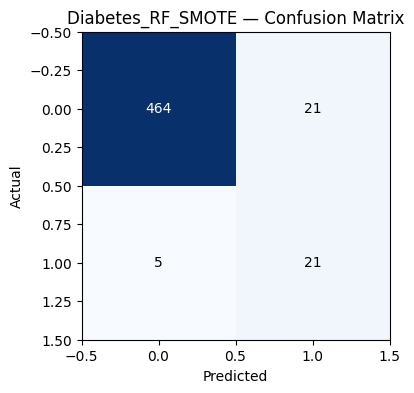

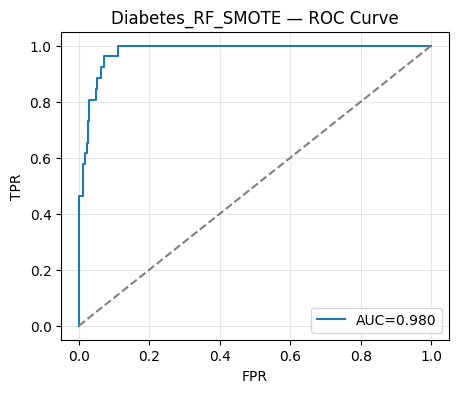

### ▶ Diabetes_XGB_SMOTE

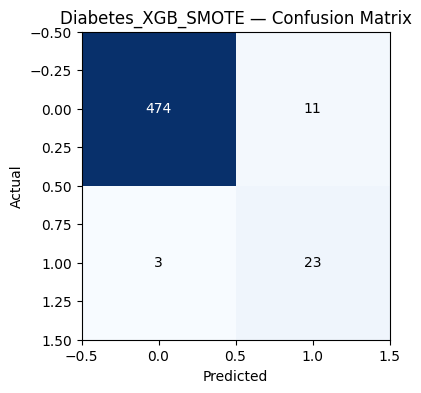

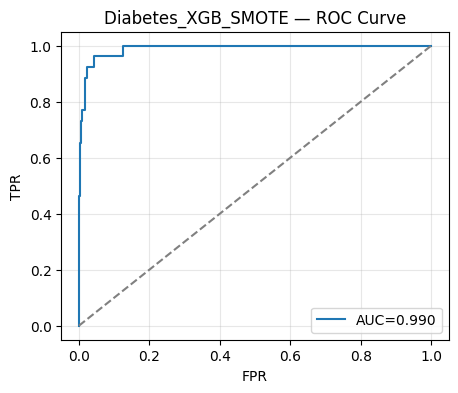

## 🟣 HRP — ROC + Confusion Matrix

### ▶ HRP_RF

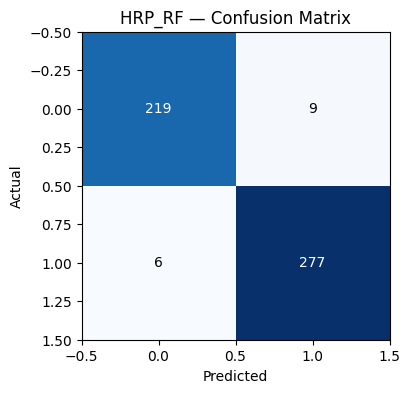

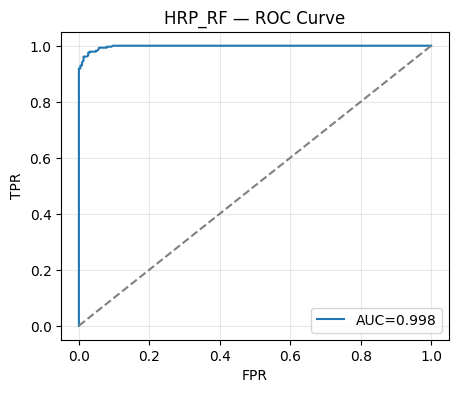

### ▶ HRP_XGB

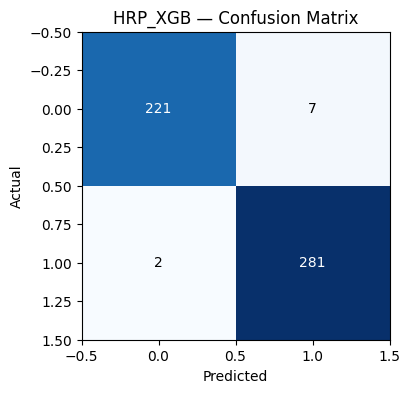

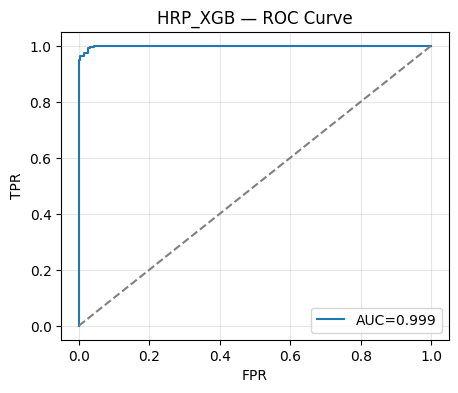

In [ ]:
# ================================================
# FIXED ROC + Confusion Matrix for ALL models
# Matches EXACT training columns
# ================================================
%matplotlib inline
import numpy as np, pandas as pd, joblib, matplotlib.pyplot as plt, os
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown

# --------------------------
# PATHS
# --------------------------
DIABETES = "/content/diabetes.csv"
HRP = "/content/Balanced_HRP_DataSet.csv"

MODELS = {
    "Diabetes_RF": "/content/best_rf_diabetes.joblib",
    "Diabetes_XGB": "/content/best_xgb_diabetes.joblib",
    "Diabetes_RF_SMOTE": "/content/best_rf_diabetes_smote.joblib",
    "Diabetes_XGB_SMOTE": "/content/best_xgb_diabetes_smote.joblib",
    "HRP_RF": "/content/best_rf_hrp.joblib",
    "HRP_XGB": "/content/best_xgb_hrp.joblib",
}

# --------------------------
# MERGE (same as used in training)
# --------------------------
def merged_data():
    df1 = pd.read_csv(DIABETES)
    df2 = pd.read_csv(HRP)

    if "Glucose" in df1: df1 = df1.rename(columns={"Glucose":"Blood Sugar"})
    if "BloodPressure" in df1: df1 = df1.rename(columns={"BloodPressure":"DiastolicBP"})

    merged = pd.merge(df1, df2,
                      on=["Blood Sugar","DiastolicBP"],
                      how="right",
                      suffixes=("_d1","_d2"))

    # missing zero → NaN
    for c in ["Insulin","BMI","SkinThickness","Blood Sugar","DiastolicBP"]:
        if c in merged: merged.loc[merged[c]==0, c] = np.nan

    # add flags
    merged["from_df1"] = merged[["Blood Sugar","DiastolicBP"]].notnull().all(axis=1).astype(int)
    merged["match_found"] = merged.filter(regex="_d1$").notna().any(axis=1).astype(int)

    # imputation
    num = merged.select_dtypes(include=[np.number]).columns
    merged[num] = merged[num].fillna(merged[num].median())
    cat = merged.select_dtypes(include=["object","category"]).columns
    for c in cat:
        merged[c] = merged[c].fillna(merged[c].mode().iloc[0])

    return merged


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4,4))
    ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha="center",va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.show()


def plot_roc(y_true, y_prob, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = auc(fpr,tpr)

    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(fpr, tpr, label=f"AUC={auc_val:.3f}")
    ax.plot([0,1],[0,1],"--",color="gray")
    ax.set_title(title)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend()
    plt.grid(alpha=0.3)
    plt.show()


# ================================================
# RUN
# ================================================
merged = merged_data()


# --------------------------
# DIABETES MODELS
# --------------------------
display(Markdown("## 🔵 Diabetes — ROC + Confusion Matrix"))

X_diab = merged.drop(columns=["Outcome"])   # KEEP RiskLevel, from_df1, match_found
y_diab = merged["Outcome"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_diab, y_diab, test_size=0.25, stratify=y_diab, random_state=42
)

for name, path in MODELS.items():
    if name.startswith("Diabetes") and os.path.exists(path):
        display(Markdown(f"### ▶ {name}"))
        pipe = joblib.load(path)

        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:,1]

        plot_cm(y_test, y_pred, f"{name} — Confusion Matrix")
        plot_roc(y_test, y_prob, f"{name} — ROC Curve")


# --------------------------
# HRP MODELS
# --------------------------
display(Markdown("## 🟣 HRP — ROC + Confusion Matrix"))

merged["RiskLevel_code"] = merged["RiskLevel"].astype("category").cat.codes

X_hrp = merged.drop(columns=["RiskLevel","RiskLevel_code"])  # KEEP Outcome, match flags
y_hrp = merged["RiskLevel_code"]

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_hrp, y_hrp, test_size=0.25, stratify=y_hrp, random_state=42
)

for name, path in MODELS.items():
    if name.startswith("HRP") and os.path.exists(path):
        display(Markdown(f"### ▶ {name}"))
        pipe = joblib.load(path)

        yh_pred = pipe.predict(Xh_test)
        yh_prob = pipe.predict_proba(Xh_test)[:,1]

        plot_cm(yh_test, yh_pred, f"{name} — Confusion Matrix")
        plot_roc(yh_test, yh_prob, f"{name} — ROC Curve")



In [ ]:
# Cell 1 - installs (Colab) and imports
!pip install -q xgboost imbalanced-learn ipywidgets >/dev/null 2>&1

import os, warnings, joblib
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
print("Libraries ready")


Libraries ready


In [ ]:
# Cell 2 - Load data (adjust paths if needed)
df_diabetes = pd.read_csv('/content/diabetes.csv')
df_hrp = pd.read_csv('/content/Balanced_HRP_DataSet.csv')

print("Diabetes shape:", df_diabetes.shape)
print("HRP shape:", df_hrp.shape)
display(df_diabetes.head())
display(df_hrp.head())


Diabetes shape: (768, 9)
HRP shape: (2000, 15)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Age,Total Pregnacies (G),Total Deliveries (P),Live Chiild (L),Abortion (A),Death (D),SystolicBP,DiastolicBP,Blood Sugar,BodyTemp,HeartRate,Hemoglobin,HBA1C,Respiration Rate,RiskLevel
0,44,4,4,3,1,0,128,68,156,100.500000,116,14.100000,5.000000,16,High Risk
1,39,6,7,4,0,0,125,69,130,102.144501,74,10.844247,4.611252,15,No Risk
2,41,2,4,1,2,1,141,67,172,99.300000,68,12.900000,4.700000,22,High Risk
3,35,3,3,1,0,0,132,83,132,99.669441,74,10.479166,6.236113,23,No Risk
4,29,9,3,4,2,1,118,98,176,100.500000,98,10.000000,5.000000,20,High Risk


HRP classes: ['High Risk' 'No Risk']

Diabetes distribution:
 Outcome
0    500
1    268
Name: count, dtype: int64

HRP distribution (encoded):
 RiskLevel_enc
1    1100
0     900
Name: count, dtype: int64


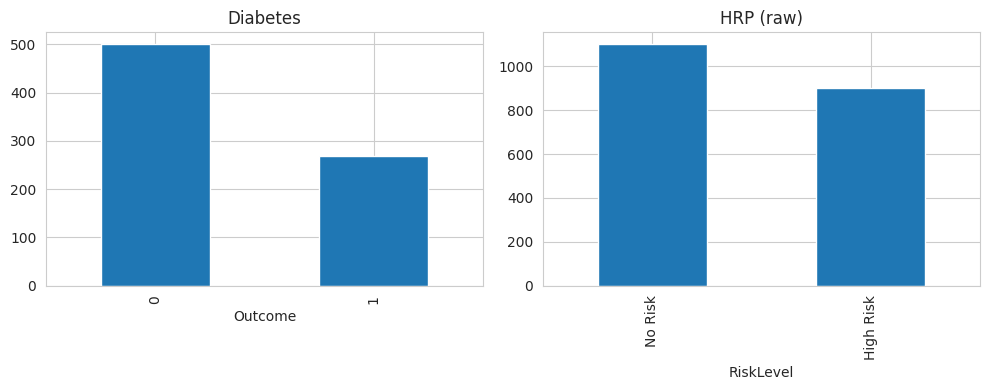

In [ ]:
# Cell 3 - encode HRP target (Label Encoding)
le_hrp = LabelEncoder()
df_hrp['RiskLevel_enc'] = le_hrp.fit_transform(df_hrp['RiskLevel'])
print("HRP classes:", le_hrp.classes_)

print("\nDiabetes distribution:\n", df_diabetes['Outcome'].value_counts())
print("\nHRP distribution (encoded):\n", df_hrp['RiskLevel_enc'].value_counts())

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); df_diabetes['Outcome'].value_counts().plot(kind='bar'); plt.title('Diabetes')
plt.subplot(1,2,2); df_hrp['RiskLevel'].value_counts().plot(kind='bar'); plt.title('HRP (raw)')
plt.tight_layout(); plt.show()


In [ ]:
# Cell 4 - Split (do not fit preprocessors here)
# Diabetes
X_d = df_diabetes.drop(columns=['Outcome'])
y_d = df_diabetes['Outcome']
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X_d, y_d, test_size=0.25, random_state=42, stratify=y_d)

# HRP (use encoded target)
X_h = df_hrp.drop(columns=['RiskLevel','RiskLevel_enc'])
y_h = df_hrp['RiskLevel_enc']
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_h, y_h, test_size=0.25, random_state=42, stratify=y_h)

print("Diabetes train/test:", Xd_train.shape, Xd_test.shape)
print("HRP train/test:", Xh_train.shape, Xh_test.shape)


Diabetes train/test: (576, 8) (192, 8)
HRP train/test: (1500, 14) (500, 14)


In [ ]:
# Cell 5 - Build preprocessor templates (do NOT fit here)
def make_preprocessor_template(X_sample):
    num_cols = X_sample.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_sample.select_dtypes(exclude=[np.number]).columns.tolist()
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])
    preproc = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)], remainder='drop')
    return preproc

preproc_template_d = make_preprocessor_template(Xd_train)
preproc_template_h = make_preprocessor_template(Xh_train)

print("Diabetes preproc columns:", Xd_train.select_dtypes(include=[np.number]).columns.tolist(), Xd_train.select_dtypes(exclude=[np.number]).columns.tolist())
print("HRP preproc columns:", Xh_train.select_dtypes(include=[np.number]).columns.tolist(), Xh_train.select_dtypes(exclude=[np.number]).columns.tolist())


Diabetes preproc columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'] []
HRP preproc columns: ['Age', 'Total Pregnacies (G)', 'Total Deliveries (P)', 'Live Chiild (L)', 'Abortion (A)', 'Death (D)', 'SystolicBP', 'DiastolicBP', 'Blood Sugar', 'BodyTemp', 'HeartRate', 'Hemoglobin', 'HBA1C', 'Respiration Rate'] []


In [ ]:
# Cell 6 - model constructors (we will build pipelines)
base_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB()
}

def make_pipeline(preproc, clf, use_smote=False):
    if use_smote:
        return ImbPipeline([('preprocess', preproc), ('smote', SMOTE(random_state=42)), ('model', clf)])
    else:
        return Pipeline([('preprocess', preproc), ('model', clf)])


In [ ]:
# Cell 7 - evaluation helper (pipe expects raw X)
def evaluate_pipeline(pipe, X_test, y_test, name='model'):
    y_pred = pipe.predict(X_test)
    probs = None
    try:
        probs = pipe.predict_proba(X_test)
    except Exception:
        probs = None

    binary = (len(np.unique(y_test)) == 2)
    if binary:
        prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1s = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    else:
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1s = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    acc = accuracy_score(y_test, y_pred)

    print(f"--- {name} ---")
    print("Accuracy:", round(acc,4))
    print("Precision:", round(prec,4))
    print("Recall:", round(rec,4))
    print("F1:", round(f1s,4))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues'); plt.title(f'{name} Confusion Matrix'); plt.xlabel('Pred'); plt.ylabel('Actual')
    if probs is not None and binary:
        plt.subplot(1,2,2)
        fpr, tpr, _ = roc_curve(y_test, probs[:,1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'AUC={roc_auc:.3f}'); plt.plot([0,1],[0,1],'--', color='gray')
        plt.title(f'{name} ROC'); plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend()
    plt.show()

    return {'accuracy':acc, 'precision':prec, 'recall':rec, 'f1':f1s, 'confusion_matrix':cm}



--- Diabetes-LogisticRegression-NoSMOTE ---
Accuracy: 0.7344
Precision: 0.6481
Recall: 0.5224
F1: 0.5785

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       125
           1       0.65      0.52      0.58        67

    accuracy                           0.73       192
   macro avg       0.71      0.69      0.69       192
weighted avg       0.73      0.73      0.73       192



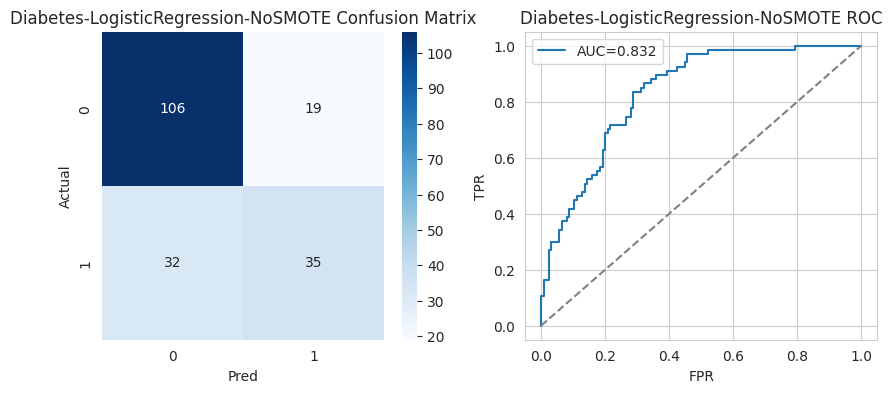


--- Diabetes-RandomForest-NoSMOTE ---
Accuracy: 0.75
Precision: 0.6727
Recall: 0.5522
F1: 0.6066

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82       125
           1       0.67      0.55      0.61        67

    accuracy                           0.75       192
   macro avg       0.73      0.70      0.71       192
weighted avg       0.74      0.75      0.74       192



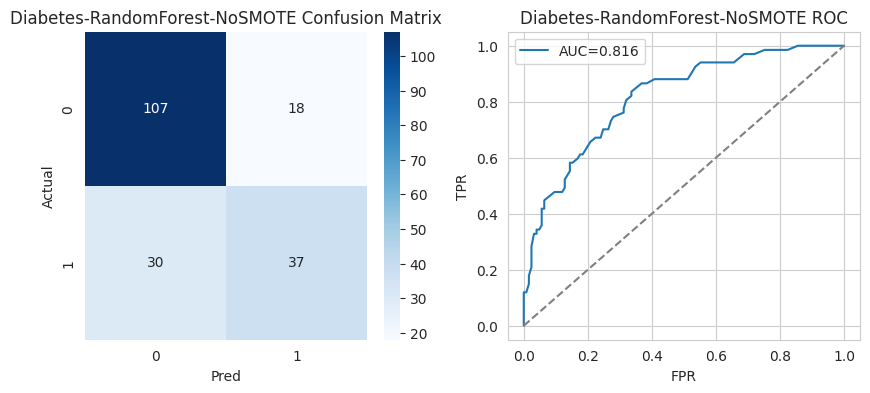


--- Diabetes-XGBoost-NoSMOTE ---
Accuracy: 0.7292
Precision: 0.6119
Recall: 0.6119
F1: 0.6119

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.79      0.79       125
           1       0.61      0.61      0.61        67

    accuracy                           0.73       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.73      0.73      0.73       192



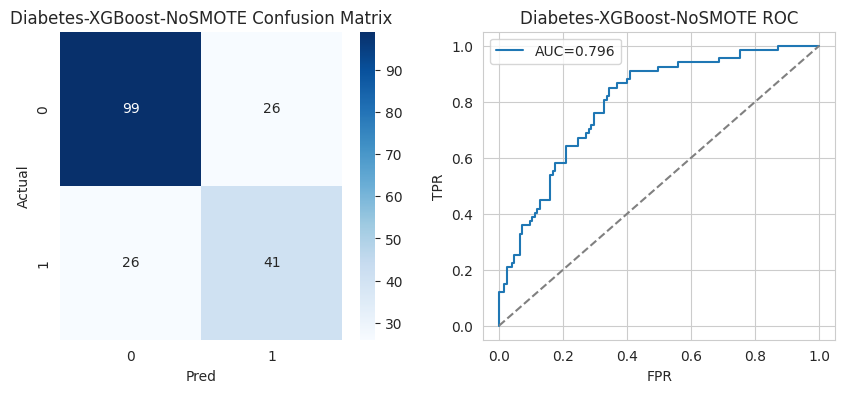


--- Diabetes-SVM-NoSMOTE ---
Accuracy: 0.75
Precision: 0.6667
Recall: 0.5672
F1: 0.6129

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       125
           1       0.67      0.57      0.61        67

    accuracy                           0.75       192
   macro avg       0.73      0.71      0.71       192
weighted avg       0.74      0.75      0.74       192



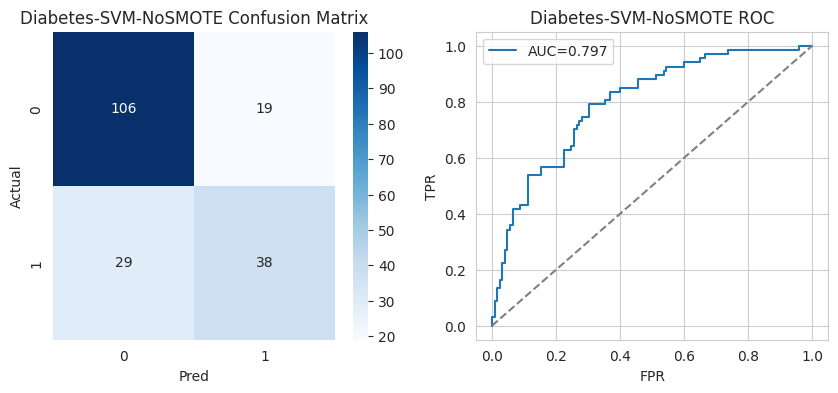


--- Diabetes-KNN-NoSMOTE ---
Accuracy: 0.7083
Precision: 0.5965
Recall: 0.5075
F1: 0.5484

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.82      0.78       125
           1       0.60      0.51      0.55        67

    accuracy                           0.71       192
   macro avg       0.68      0.66      0.67       192
weighted avg       0.70      0.71      0.70       192



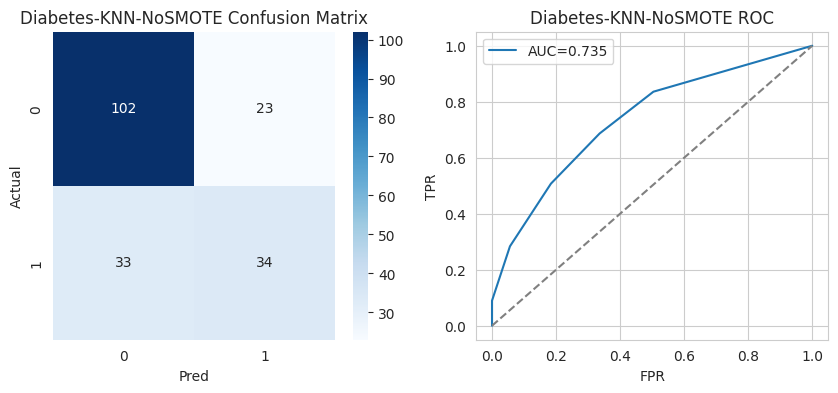


--- Diabetes-NaiveBayes-NoSMOTE ---
Accuracy: 0.7135
Precision: 0.5857
Recall: 0.6119
F1: 0.5985

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78       125
           1       0.59      0.61      0.60        67

    accuracy                           0.71       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.72      0.71      0.71       192



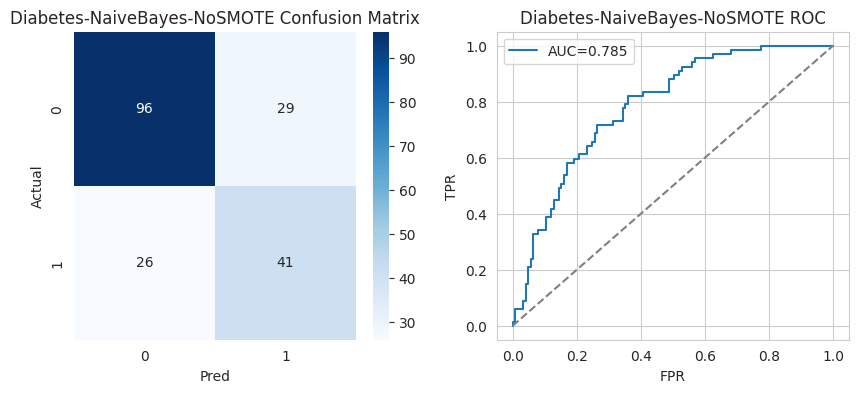

In [ ]:
# Cell 8 - Diabetes baseline WITHOUT SMOTE
results_d_no_smote = {}
for name, clf in base_models.items():
    pipe = make_pipeline(preproc_template_d, clf, use_smote=False)
    pipe.fit(Xd_train, yd_train)   # fit preproc on train inside pipeline
    print()
    results_d_no_smote[name] = evaluate_pipeline(pipe, Xd_test, yd_test, name=f"Diabetes-{name}-NoSMOTE")



--- HRP-LogisticRegression-NoSMOTE ---
Accuracy: 0.974
Precision: 0.9613
Recall: 0.9927
F1: 0.9767

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97       225
           1       0.96      0.99      0.98       275

    accuracy                           0.97       500
   macro avg       0.98      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



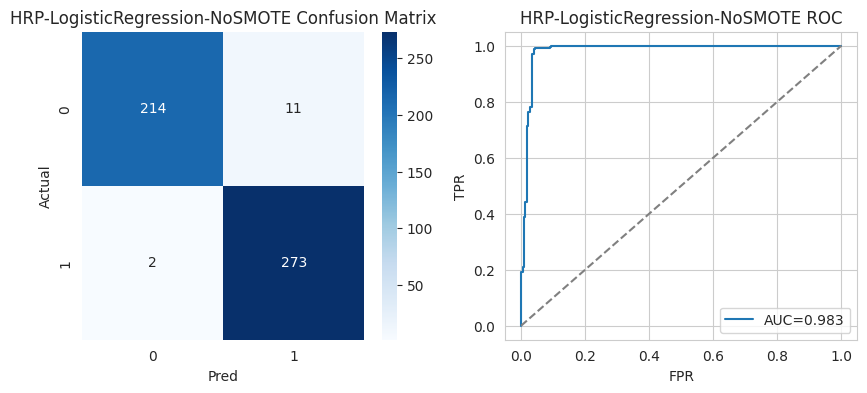


--- HRP-RandomForest-NoSMOTE ---
Accuracy: 0.996
Precision: 0.9928
Recall: 1.0
F1: 0.9964

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       225
           1       0.99      1.00      1.00       275

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



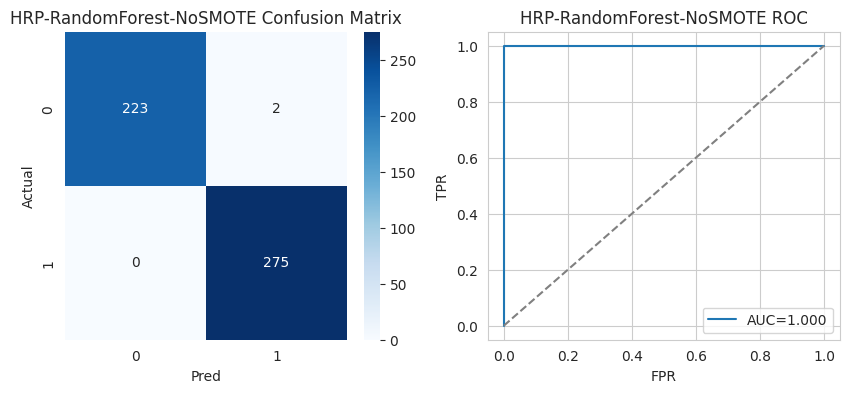


--- HRP-XGBoost-NoSMOTE ---
Accuracy: 0.996
Precision: 0.9928
Recall: 1.0
F1: 0.9964

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       225
           1       0.99      1.00      1.00       275

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



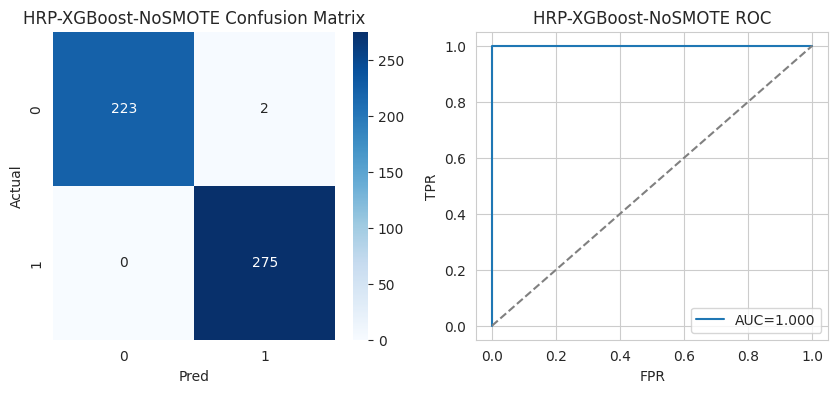


--- HRP-SVM-NoSMOTE ---
Accuracy: 0.992
Precision: 0.9857
Recall: 1.0
F1: 0.9928

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       225
           1       0.99      1.00      0.99       275

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



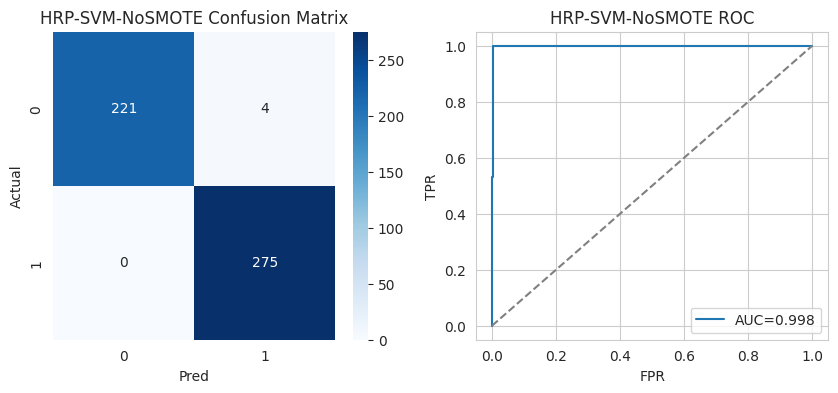


--- HRP-KNN-NoSMOTE ---
Accuracy: 0.94
Precision: 0.9016
Recall: 1.0
F1: 0.9483

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93       225
           1       0.90      1.00      0.95       275

    accuracy                           0.94       500
   macro avg       0.95      0.93      0.94       500
weighted avg       0.95      0.94      0.94       500



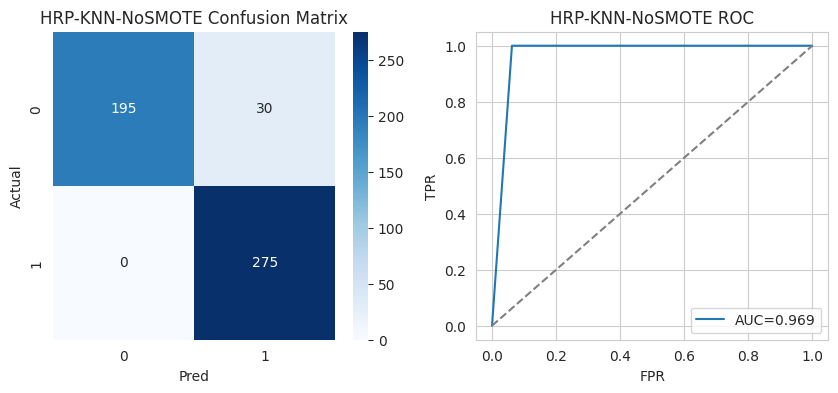


--- HRP-NaiveBayes-NoSMOTE ---
Accuracy: 0.934
Precision: 0.8929
Recall: 1.0
F1: 0.9434

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92       225
           1       0.89      1.00      0.94       275

    accuracy                           0.93       500
   macro avg       0.95      0.93      0.93       500
weighted avg       0.94      0.93      0.93       500



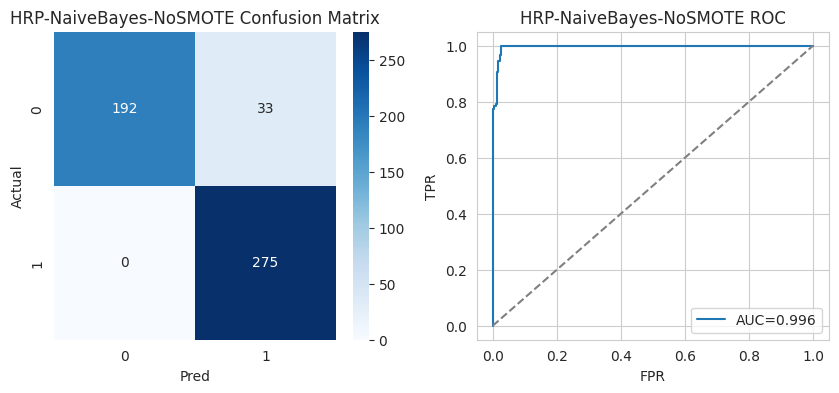

In [ ]:
# Cell 9 - HRP baseline WITHOUT SMOTE
results_h_no_smote = {}
for name, clf in base_models.items():
    pipe = make_pipeline(preproc_template_h, clf, use_smote=False)
    pipe.fit(Xh_train, yh_train)
    print()
    results_h_no_smote[name] = evaluate_pipeline(pipe, Xh_test, yh_test, name=f"HRP-{name}-NoSMOTE")



--- Diabetes-LogisticRegression-SMOTE ---
Accuracy: 0.7396
Precision: 0.6133
Recall: 0.6866
F1: 0.6479

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.79       125
           1       0.61      0.69      0.65        67

    accuracy                           0.74       192
   macro avg       0.72      0.73      0.72       192
weighted avg       0.75      0.74      0.74       192



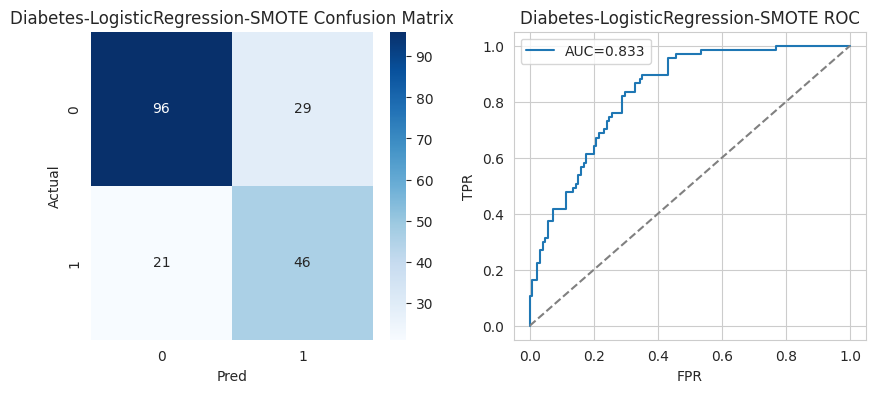


--- Diabetes-RandomForest-SMOTE ---
Accuracy: 0.7344
Precision: 0.6176
Recall: 0.6269
F1: 0.6222

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       125
           1       0.62      0.63      0.62        67

    accuracy                           0.73       192
   macro avg       0.71      0.71      0.71       192
weighted avg       0.74      0.73      0.73       192



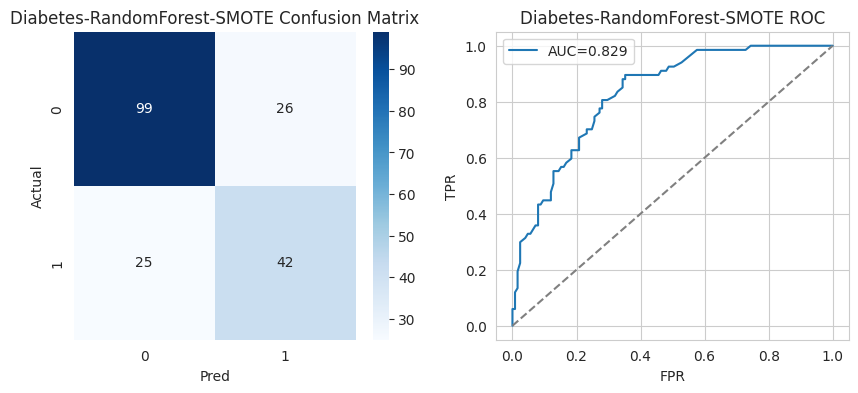


--- Diabetes-XGBoost-SMOTE ---
Accuracy: 0.7552
Precision: 0.6429
Recall: 0.6716
F1: 0.6569

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81       125
           1       0.64      0.67      0.66        67

    accuracy                           0.76       192
   macro avg       0.73      0.74      0.73       192
weighted avg       0.76      0.76      0.76       192



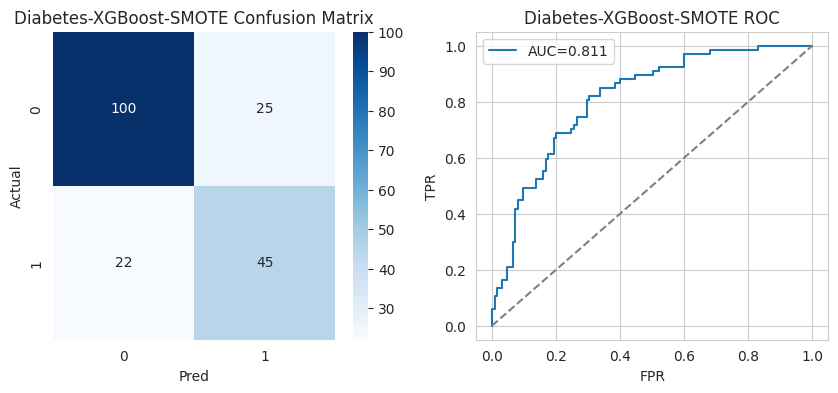


--- Diabetes-SVM-SMOTE ---
Accuracy: 0.7292
Precision: 0.5926
Recall: 0.7164
F1: 0.6486

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.74      0.78       125
           1       0.59      0.72      0.65        67

    accuracy                           0.73       192
   macro avg       0.71      0.73      0.71       192
weighted avg       0.75      0.73      0.73       192



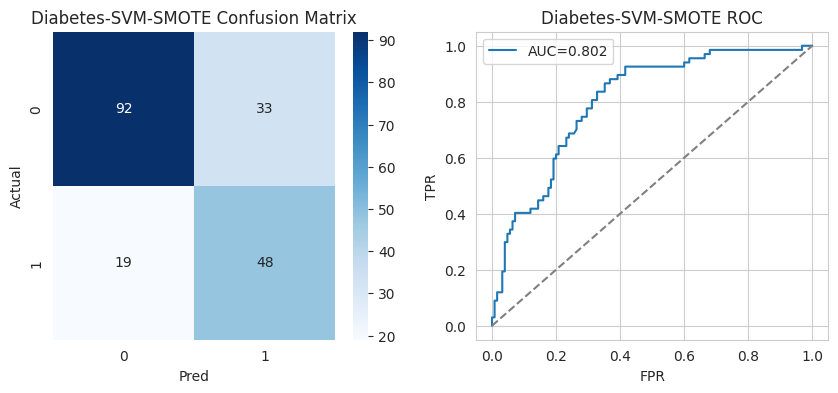


--- Diabetes-KNN-SMOTE ---
Accuracy: 0.6719
Precision: 0.5233
Recall: 0.6716
F1: 0.5882

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.67      0.73       125
           1       0.52      0.67      0.59        67

    accuracy                           0.67       192
   macro avg       0.66      0.67      0.66       192
weighted avg       0.70      0.67      0.68       192



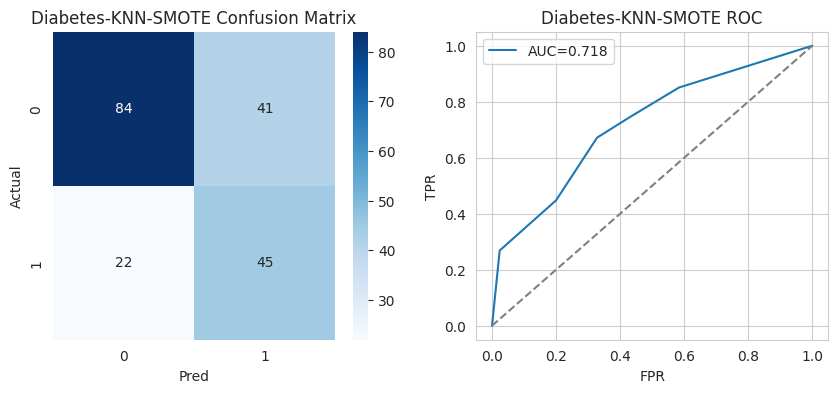


--- Diabetes-NaiveBayes-SMOTE ---
Accuracy: 0.7344
Precision: 0.6
Recall: 0.7164
F1: 0.6531

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.74      0.78       125
           1       0.60      0.72      0.65        67

    accuracy                           0.73       192
   macro avg       0.72      0.73      0.72       192
weighted avg       0.75      0.73      0.74       192



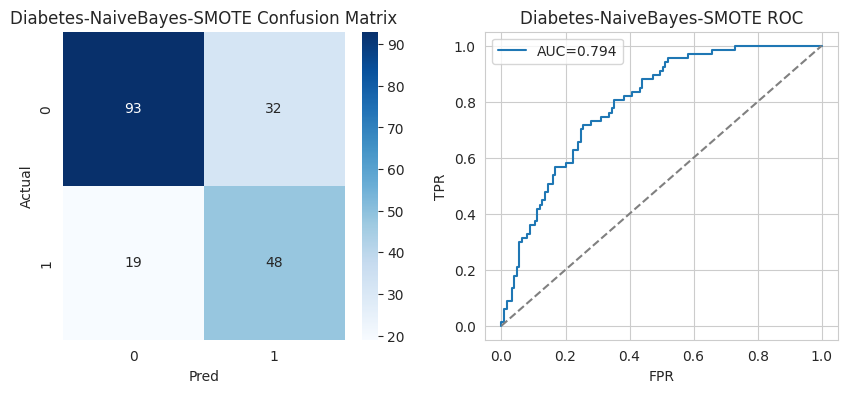

In [ ]:
# Cell 10 - Diabetes WITH SMOTE
results_d_smote = {}
for name, clf in base_models.items():
    pipe = make_pipeline(preproc_template_d, clf, use_smote=True)
    pipe.fit(Xd_train, yd_train)   # fit: preprocessor + SMOTE + model on TRAIN
    print()
    results_d_smote[name] = evaluate_pipeline(pipe, Xd_test, yd_test, name=f"Diabetes-{name}-SMOTE")



--- HRP-LogisticRegression-SMOTE ---
Accuracy: 0.976
Precision: 0.9647
Recall: 0.9927
F1: 0.9785

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.97       225
           1       0.96      0.99      0.98       275

    accuracy                           0.98       500
   macro avg       0.98      0.97      0.98       500
weighted avg       0.98      0.98      0.98       500



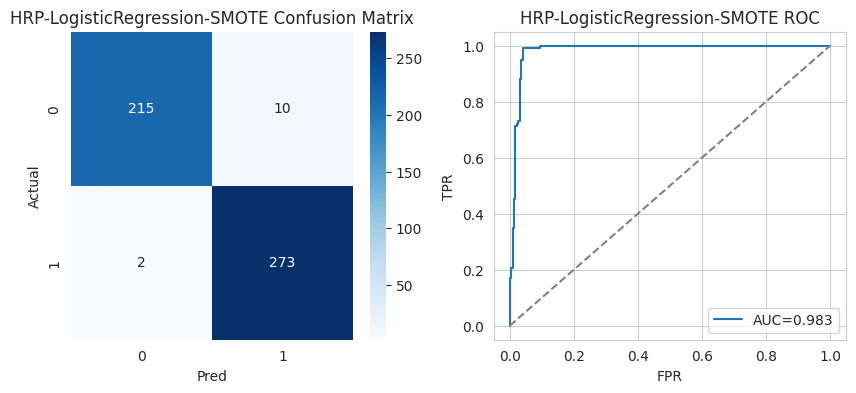


--- HRP-RandomForest-SMOTE ---
Accuracy: 0.998
Precision: 0.9964
Recall: 1.0
F1: 0.9982

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       275

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



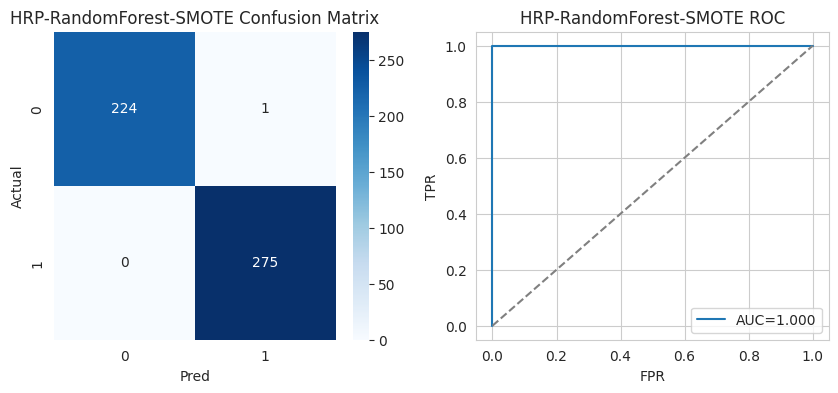


--- HRP-XGBoost-SMOTE ---
Accuracy: 0.996
Precision: 0.9928
Recall: 1.0
F1: 0.9964

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       225
           1       0.99      1.00      1.00       275

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



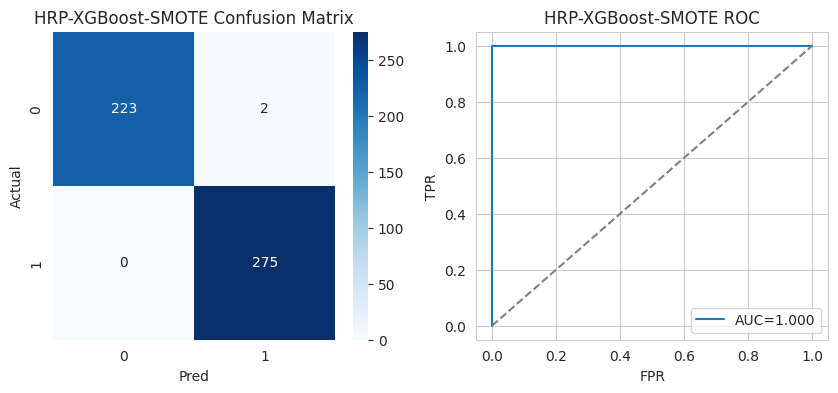


--- HRP-SVM-SMOTE ---
Accuracy: 0.992
Precision: 0.9857
Recall: 1.0
F1: 0.9928

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       225
           1       0.99      1.00      0.99       275

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



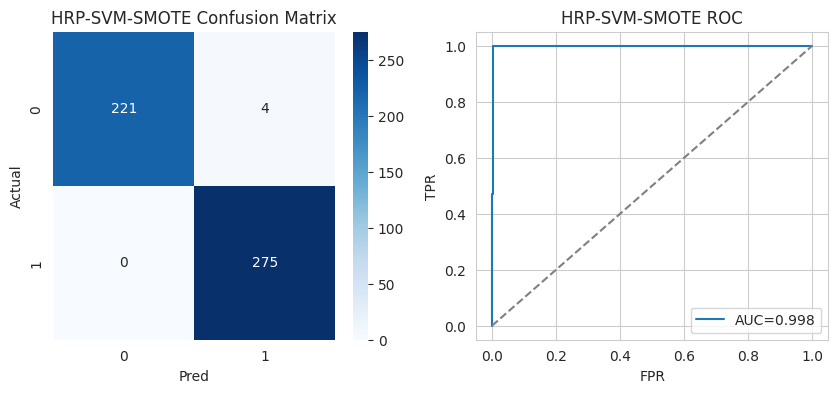


--- HRP-KNN-SMOTE ---
Accuracy: 0.946
Precision: 0.9106
Recall: 1.0
F1: 0.9532

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.88      0.94       225
           1       0.91      1.00      0.95       275

    accuracy                           0.95       500
   macro avg       0.96      0.94      0.94       500
weighted avg       0.95      0.95      0.95       500



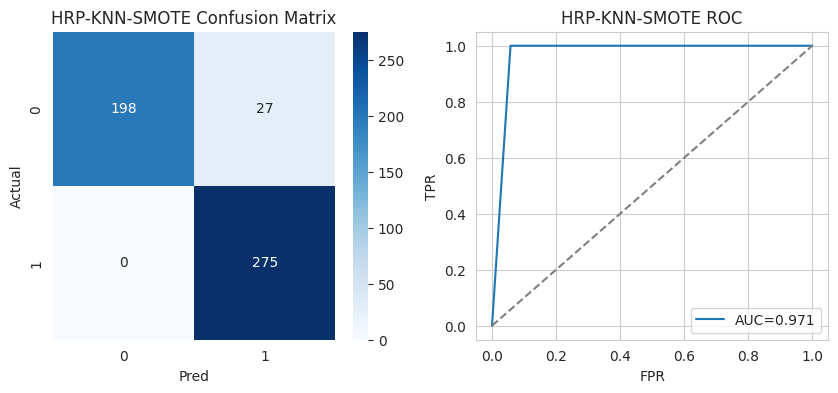


--- HRP-NaiveBayes-SMOTE ---
Accuracy: 0.934
Precision: 0.8929
Recall: 1.0
F1: 0.9434

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92       225
           1       0.89      1.00      0.94       275

    accuracy                           0.93       500
   macro avg       0.95      0.93      0.93       500
weighted avg       0.94      0.93      0.93       500



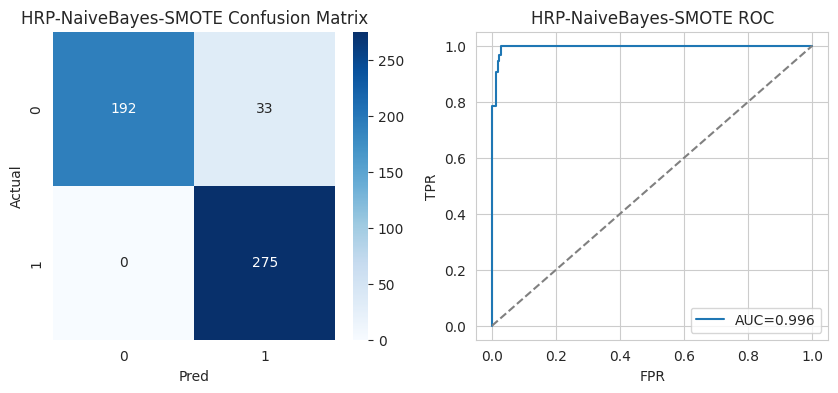

In [ ]:
# Cell 11 - HRP WITH SMOTE
results_h_smote = {}
for name, clf in base_models.items():
    pipe = make_pipeline(preproc_template_h, clf, use_smote=True)
    pipe.fit(Xh_train, yh_train)
    print()
    results_h_smote[name] = evaluate_pipeline(pipe, Xh_test, yh_test, name=f"HRP-{name}-SMOTE")


In [ ]:
# Cell 12 - comparison tables
def summaries_from_results(res_dict):
    rows=[]
    for name,metrics in res_dict.items():
        rows.append({'model':name,'accuracy':metrics['accuracy'],'precision':metrics['precision'],'recall':metrics['recall'],'f1':metrics['f1']})
    return pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)

print("Diabetes - NO SMOTE")
display(summaries_from_results(results_d_no_smote))
print("\nDiabetes - WITH SMOTE")
display(summaries_from_results(results_d_smote))
print("\nHRP - NO SMOTE")
display(summaries_from_results(results_h_no_smote))
print("\nHRP - WITH SMOTE")
display(summaries_from_results(results_h_smote))


Diabetes - NO SMOTE


,model,accuracy,precision,recall,f1
0,SVM,0.750000,0.666667,0.567164,0.612903
1,XGBoost,0.729167,0.611940,0.611940,0.611940
2,RandomForest,0.750000,0.672727,0.552239,0.606557
3,NaiveBayes,0.713542,0.585714,0.611940,0.598540
4,LogisticRegression,0.734375,0.648148,0.522388,0.578512
5,KNN,0.708333,0.596491,0.507463,0.548387



Diabetes - WITH SMOTE


,model,accuracy,precision,recall,f1
0,XGBoost,0.755208,0.642857,0.671642,0.656934
1,NaiveBayes,0.734375,0.600000,0.716418,0.653061
2,SVM,0.729167,0.592593,0.716418,0.648649
3,LogisticRegression,0.739583,0.613333,0.686567,0.647887
4,RandomForest,0.734375,0.617647,0.626866,0.622222
5,KNN,0.671875,0.523256,0.671642,0.588235



HRP - NO SMOTE


,model,accuracy,precision,recall,f1
0,RandomForest,0.996,0.992780,1.000000,0.996377
1,XGBoost,0.996,0.992780,1.000000,0.996377
2,SVM,0.992,0.985663,1.000000,0.992780
3,LogisticRegression,0.974,0.961268,0.992727,0.976744
4,KNN,0.940,0.901639,1.000000,0.948276
5,NaiveBayes,0.934,0.892857,1.000000,0.943396



HRP - WITH SMOTE


,model,accuracy,precision,recall,f1
0,RandomForest,0.998,0.996377,1.000000,0.998185
1,XGBoost,0.996,0.992780,1.000000,0.996377
2,SVM,0.992,0.985663,1.000000,0.992780
3,LogisticRegression,0.976,0.964664,0.992727,0.978495
4,KNN,0.946,0.910596,1.000000,0.953206
5,NaiveBayes,0.934,0.892857,1.000000,0.943396


In [ ]:
# Cell 13 - choose best by F1 (prefer SMOTE if better)
df_d_no = summaries_from_results(results_d_no_smote)
df_d_sm = summaries_from_results(results_d_smote)
best_d_name = df_d_sm.loc[0,'model'] if df_d_sm.loc[0,'f1'] >= df_d_no.loc[0,'f1'] else df_d_no.loc[0,'model']
print("Chosen Diabetes model:", best_d_name)

df_h_no = summaries_from_results(results_h_no_smote)
df_h_sm = summaries_from_results(results_h_smote)
best_h_name = df_h_sm.loc[0,'model'] if df_h_sm.loc[0,'f1'] >= df_h_no.loc[0,'f1'] else df_h_no.loc[0,'model']
print("Chosen HRP model:", best_h_name)


Chosen Diabetes model: XGBoost
Chosen HRP model: RandomForest


In [ ]:
# Cell 14 - tuning param grids (we tune pipelines with SMOTE so the returned best_estimator_ is a pipeline)
from sklearn.model_selection import RandomizedSearchCV

rf_param = {'model__n_estimators':[100,200,300], 'model__max_depth':[None,5,10], 'model__class_weight':[None,'balanced']}
xgb_param = {'model__n_estimators':[100,200,300], 'model__learning_rate':[0.01,0.05,0.1], 'model__max_depth':[3,5,7]}

best_rf_d = best_xgb_d = None
best_rf_h = best_xgb_h = None

# Tune for Diabetes if selected model is RF or XGB
if best_d_name in ['RandomForest','XGBoost']:
    print("Tuning for Diabetes:", best_d_name)
    if best_d_name == 'RandomForest':
        base_pipe = make_pipeline(preproc_template_d, RandomForestClassifier(random_state=42), use_smote=True)
        search = RandomizedSearchCV(base_pipe, rf_param, n_iter=6, scoring='f1', cv=3, random_state=42, n_jobs=-1)
        search.fit(Xd_train, yd_train)
        best_rf_d = search.best_estimator_
        print("Best RF (Diabetes) params:", search.best_params_)
    else:
        base_pipe = make_pipeline(preproc_template_d, XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), use_smote=True)
        search = RandomizedSearchCV(base_pipe, xgb_param, n_iter=6, scoring='f1', cv=3, random_state=42, n_jobs=-1)
        search.fit(Xd_train, yd_train)
        best_xgb_d = search.best_estimator_
        print("Best XGB (Diabetes) params:", search.best_params_)

# Tune for HRP
if best_h_name in ['RandomForest','XGBoost']:
    print("Tuning for HRP:", best_h_name)
    if best_h_name == 'RandomForest':
        base_pipe = make_pipeline(preproc_template_h, RandomForestClassifier(random_state=42), use_smote=True)
        search_h = RandomizedSearchCV(base_pipe, rf_param, n_iter=6, scoring='f1', cv=3, random_state=42, n_jobs=-1)
        search_h.fit(Xh_train, yh_train)
        best_rf_h = search_h.best_estimator_
        print("Best RF (HRP) params:", search_h.best_params_)
    else:
        base_pipe = make_pipeline(preproc_template_h, XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), use_smote=True)
        search_h = RandomizedSearchCV(base_pipe, xgb_param, n_iter=6, scoring='f1', cv=3, random_state=42, n_jobs=-1)
        search_h.fit(Xh_train, yh_train)
        best_xgb_h = search_h.best_estimator_
        print("Best XGB (HRP) params:", search_h.best_params_)


Tuning for Diabetes: XGBoost
Best XGB (Diabetes) params: {'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05}
Tuning for HRP: RandomForest
Best RF (HRP) params: {'model__n_estimators': 300, 'model__max_depth': 10, 'model__class_weight': None}



Tuned XGB (Diabetes):
--- Diabetes-XGB-Tuned ---
Accuracy: 0.7396
Precision: 0.6164
Recall: 0.6716
F1: 0.6429

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.78      0.80       125
           1       0.62      0.67      0.64        67

    accuracy                           0.74       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.75      0.74      0.74       192



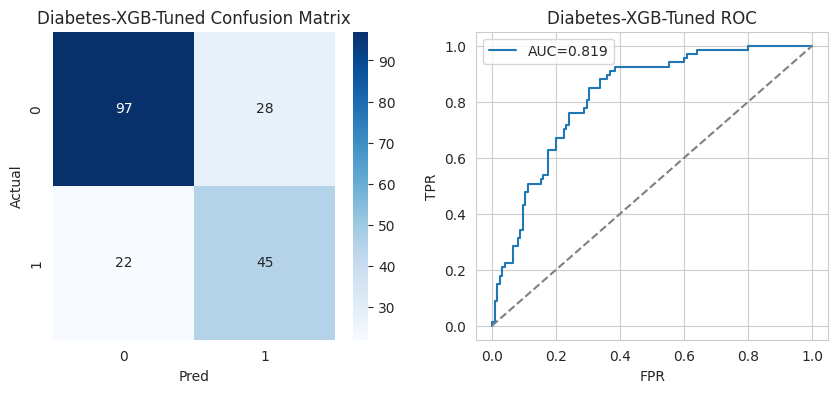


Tuned RF (HRP):
--- HRP-RF-Tuned ---
Accuracy: 0.998
Precision: 0.9964
Recall: 1.0
F1: 0.9982

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       225
           1       1.00      1.00      1.00       275

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



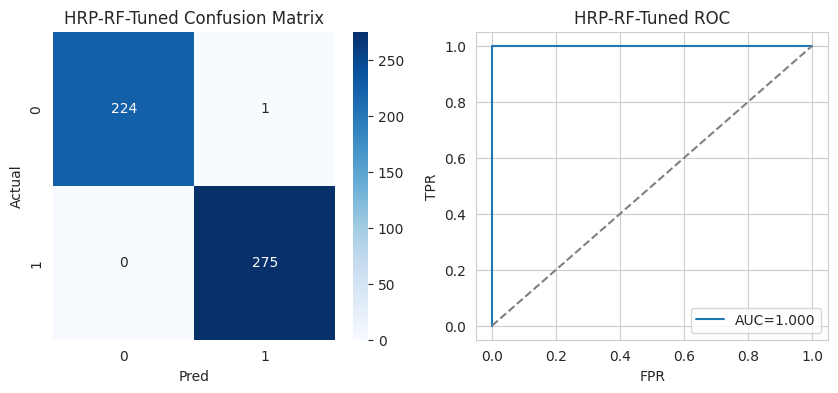

In [ ]:
# Cell 15 - evaluate tuned pipelines if available
if best_rf_d is not None:
    print("\nTuned RF (Diabetes):")
    _ = evaluate_pipeline(best_rf_d, Xd_test, yd_test, name='Diabetes-RF-Tuned')
if best_xgb_d is not None:
    print("\nTuned XGB (Diabetes):")
    _ = evaluate_pipeline(best_xgb_d, Xd_test, yd_test, name='Diabetes-XGB-Tuned')

if best_rf_h is not None:
    print("\nTuned RF (HRP):")
    _ = evaluate_pipeline(best_rf_h, Xh_test, yh_test, name='HRP-RF-Tuned')
if best_xgb_h is not None:
    print("\nTuned XGB (HRP):")
    _ = evaluate_pipeline(best_xgb_h, Xh_test, yh_test, name='HRP-XGB-Tuned')


In [ ]:
# Cell 16 - assemble final pipelines (prefer tuned pipeline if present)
final_d_candidates = {}
if best_xgb_d is not None:
    final_d_candidates['XGB_tuned'] = best_xgb_d
if best_rf_d is not None:
    final_d_candidates['RF_tuned'] = best_rf_d
# fallback: choose the chosen model pipeline from earlier results (SMOTE)
chosen_prev_d = make_pipeline(preproc_template_d, base_models[best_d_name], use_smote=True)
chosen_prev_d.fit(Xd_train, yd_train)
final_d_candidates['previous_best'] = chosen_prev_d

# pick best by F1 on test
best_d_final = None; best_d_f1=-1
for k,pipe in final_d_candidates.items():
    preds = pipe.predict(Xd_test)
    f1s = f1_score(yd_test, preds, zero_division=0)
    print("Diabetes candidate:", k, "F1:", f1s)
    if f1s > best_d_f1:
        best_d_f1 = f1s; best_d_final = pipe
print("Selected Diabetes final pipeline F1:", best_d_f1)

# HRP final candidates
final_h_candidates = {}
if best_xgb_h is not None:
    final_h_candidates['XGB_tuned'] = best_xgb_h
if best_rf_h is not None:
    final_h_candidates['RF_tuned'] = best_rf_h
chosen_prev_h = make_pipeline(preproc_template_h, base_models[best_h_name], use_smote=True)
chosen_prev_h.fit(Xh_train, yh_train)
final_h_candidates['previous_best'] = chosen_prev_h

best_h_final = None; best_h_f1=-1
for k,pipe in final_h_candidates.items():
    preds = pipe.predict(Xh_test)
    f1s = f1_score(yh_test, preds, average='weighted', zero_division=0)
    print("HRP candidate:", k, "F1:", f1s)
    if f1s > best_h_f1:
        best_h_f1 = f1s; best_h_final = pipe
print("Selected HRP final pipeline F1:", best_h_f1)


Diabetes candidate: XGB_tuned F1: 0.6428571428571429
Diabetes candidate: previous_best F1: 0.656934306569343
Selected Diabetes final pipeline F1: 0.656934306569343
HRP candidate: RF_tuned F1: 0.9979995877105405
HRP candidate: previous_best F1: 0.9979995877105405
Selected HRP final pipeline F1: 0.9979995877105405


Diabetes feature importances (if available):
DEBUG: Model type for Diabetes feature importances: <class 'xgboost.sklearn.XGBClassifier'>
DEBUG: Has 'feature_importances_' attribute: True


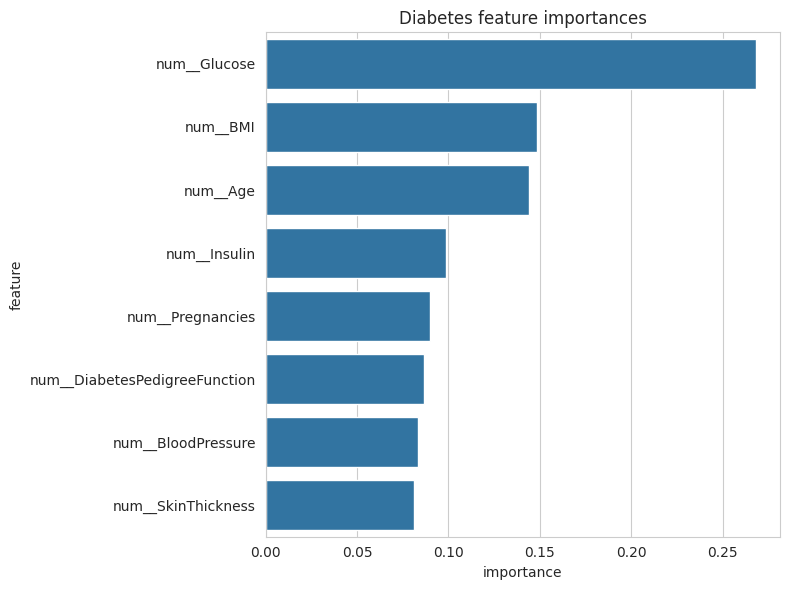

HRP feature importances (if available):
DEBUG: Model type for HRP feature importances: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
DEBUG: Has 'feature_importances_' attribute: True


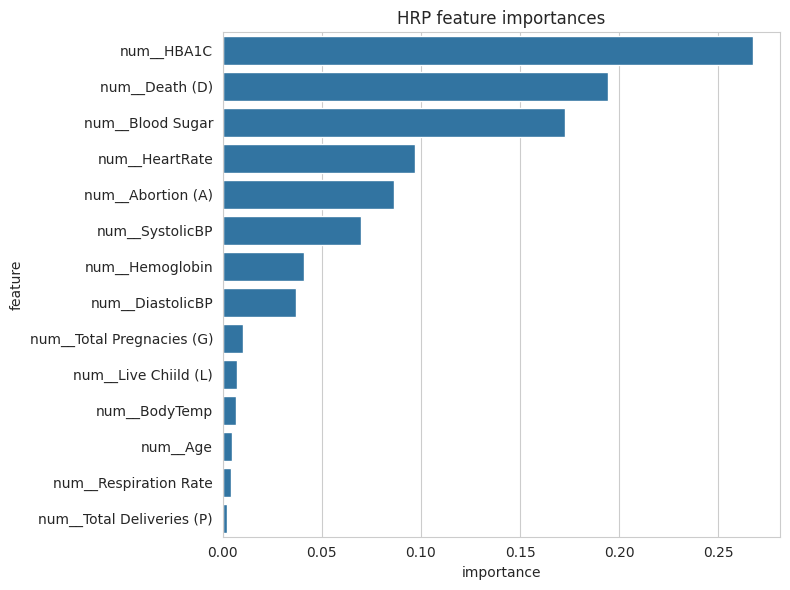

In [ ]:
# Cell 17 - feature importance if model supports it (extract model from pipeline)
def plot_importances(pipe, X_train_raw, top_n=10, title='Feature importance'):
    est = pipe.named_steps['model'] if 'model' in pipe.named_steps else None
    pre = pipe.named_steps['preprocess']

    print(f"DEBUG: Model type for {title}: {type(est)}")
    print(f"DEBUG: Has 'feature_importances_' attribute: {hasattr(est, 'feature_importances_')}")

    if est is None or not hasattr(est, 'feature_importances_'):
        print("Feature importances not available for this model.")
        return

    # Use the ColumnTransformer's get_feature_names_out method
    # This method is available after the ColumnTransformer itself has been fitted.
    try:
        feature_names = pre.get_feature_names_out()
    except NotFittedError:
        print("Preprocessor not fitted, cannot get feature names.")
        return

    fi = est.feature_importances_
    df = pd.DataFrame({'feature': feature_names, 'importance': fi})
    df = df.sort_values('importance', ascending=False).head(top_n)
    plt.figure(figsize=(8,6)); sns.barplot(x='importance', y='feature', data=df); plt.title(title); plt.tight_layout(); plt.show()

print("Diabetes feature importances (if available):")
plot_importances(best_d_final, Xd_train, top_n=10, title='Diabetes feature importances')

print("HRP feature importances (if available):")
plot_importances(best_h_final, Xh_train, top_n=15, title='HRP feature importances')

In [ ]:
# Cell 18 - save final pipelines and label encoder
os.makedirs('/mnt/data/saved_models', exist_ok=True)
joblib.dump(best_d_final, '/mnt/data/saved_models/best_model_diabetes_pipeline.pkl')
joblib.dump(best_h_final, '/mnt/data/saved_models/best_model_hrp_pipeline.pkl')
joblib.dump(le_hrp, '/mnt/data/saved_models/le_hrp.pkl')
print("Saved final pipelines & encoder to /mnt/data/saved_models/")


Saved final pipelines & encoder to /mnt/data/saved_models/


In [ ]:
# Cell 19 - combined predict function (accept raw dicts matching column names)
best_d = joblib.load('/mnt/data/saved_models/best_model_diabetes_pipeline.pkl')
best_h = joblib.load('/mnt/data/saved_models/best_model_hrp_pipeline.pkl')
le_hrp = joblib.load('/mnt/data/saved_models/le_hrp.pkl')

def combined_predict_raw(diabetes_input: dict, hrp_input: dict):
    Xd = pd.DataFrame([diabetes_input])
    Xh = pd.DataFrame([hrp_input])
    d_pred = int(best_d.predict(Xd)[0])
    h_pred_enc = int(best_h.predict(Xh)[0])
    h_pred_label = le_hrp.inverse_transform([h_pred_enc])[0]
    d_proba = best_d.predict_proba(Xd)[0] if hasattr(best_d, 'predict_proba') else None
    h_proba = best_h.predict_proba(Xh)[0] if hasattr(best_h, 'predict_proba') else None
    return {'diabetes_pred': d_pred, 'diabetes_proba': d_proba, 'hrp_pred_enc': h_pred_enc, 'hrp_pred_label': h_pred_label, 'hrp_proba': h_proba}

# Example using medians:
diab_example = {c: float(Xd_train[c].median()) for c in Xd_train.columns}
hrp_example = {c: float(Xh_train[c].median()) for c in Xh_train.columns}
print("Example output:", combined_predict_raw(diab_example, hrp_example))


Example output: {'diabetes_pred': 1, 'diabetes_proba': array([0.31230098, 0.687699  ], dtype=float32), 'hrp_pred_enc': 1, 'hrp_pred_label': 'No Risk', 'hrp_proba': array([0.00391421, 0.99608579])}


In [ ]:
# Cell 20 - ipywidgets interactive input UI and CLI fallback
try:
    import ipywidgets as widgets
    from IPython.display import display, HTML
    widget_ok = True
except Exception:
    widget_ok = False

if widget_ok:
    dia_cols = list(Xd_train.columns); hrp_cols = list(Xh_train.columns)
    dia_widgets = {c: widgets.FloatText(description=c, value=float(Xd_train[c].median())) for c in dia_cols}
    hrp_widgets = {c: widgets.FloatText(description=c, value=float(Xh_train[c].median())) for c in hrp_cols}
    btn = widgets.Button(description='Predict', button_style='success')
    out = widgets.Output()
    def on_click(b):
        with out:
            out.clear_output()
            d_in = {c: dia_widgets[c].value for c in dia_cols}
            h_in = {c: hrp_widgets[c].value for c in hrp_cols}
            print(combined_predict_raw(d_in, h_in))
    btn.on_click(on_click)
    display(HTML('<h4>Enter Diabetes features (left) and HRP features (right)</h4>'))
    display(widgets.HBox([widgets.VBox(list(dia_widgets.values())), widgets.VBox(list(hrp_widgets.values()))]))
    display(btn, out)
else:
    print("ipywidgets not available — use cli_combined_predict() below")

def cli_combined_predict():
    d_in = {}
    print("Enter Diabetes features (blank = median):")
    for c in Xd_train.columns:
        val = input(f"{c} [{float(Xd_train[c].median())}]: ")
        d_in[c] = float(val) if val.strip()!='' else float(Xd_train[c].median())
    h_in = {}
    print("Enter HRP features (blank = median):")
    for c in Xh_train.columns:
        val = input(f"{c} [{float(Xh_train[c].median())}]: ")
        h_in[c] = float(val) if val.strip()!='' else float(Xh_train[c].median())
    print("Prediction:", combined_predict_raw(d_in, h_in))


Button(button_style='success', description='Predict', style=ButtonStyle())

Output()

In [ ]:
# Final notes
#- We **split first**, then all preprocessing is performed inside pipelines fit on TRAIN only (no leakage).
#- SMOTE is applied only in training pipelines (imblearn pipelines).
#- Randomized hyperparameter tuning for RF & XGB uses pipelines with SMOTE — the `best_estimator_` returned is a pipeline, so no post-wrapping is required.
#- Final pipelines are saved under `/mnt/data/saved_models/`.
#- Use `combined_predict_raw()` or the UI to get combined diabetes + HRP output.
